# **TAKE HOME TEST PROJECT - NOTEBOOK 2**

# Ecommerce Revenue Leakage & Operational Intelligence



```
Name: Akmal Zuhdy Prasetya
Class: Data Analytics & Business Intelligence
Batch: 19
```

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Datasets

### users_cleaned.csv

In [ ]:
df_users_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/users_cleaned.csv')

In [ ]:
df_users_cleaned.head()

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,account_created_year,account_created_month
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2022-07-19 13:51:00+00:00,2022,7
1,6578,Elizabeth,Martinez,elizabethmartinez@example.com,34,F,Acre,1705 Nielsen Land,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2023-11-08 18:49:00+00:00,2023,11
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Email,2019-08-24 06:10:00+00:00,2019,8
3,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-02-15 11:26:00+00:00,2020,2
4,64231,Natasha,Wilson,natashawilson@example.net,25,F,Acre,20798 Phillip Trail Apt. 392,69917-400,Rio Branco,Brasil,-9.945568,-67.83561,Search,2020-03-13 06:45:00+00:00,2020,3


In [ ]:
df_users_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     100000 non-null  int64  
 1   first_name             100000 non-null  object 
 2   last_name              100000 non-null  object 
 3   email                  100000 non-null  object 
 4   age                    100000 non-null  int64  
 5   gender                 100000 non-null  object 
 6   state                  100000 non-null  object 
 7   street_address         100000 non-null  object 
 8   postal_code            100000 non-null  object 
 9   city                   100000 non-null  object 
 10  country                100000 non-null  object 
 11  latitude               100000 non-null  float64
 12  longitude              100000 non-null  float64
 13  traffic_source         100000 non-null  object 
 14  created_at             100000 non-nul

### products_cleaned.csv

In [ ]:
df_products_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/products_cleaned.csv')

In [ ]:
df_products_cleaned.head()

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id,profit_per_product,profit_margin_pct
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1,3.73125,59.7
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1,3.61165,60.7
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1,6.11044,55.6
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1,6.34123,57.7
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1,9.48207,59.3


In [ ]:
df_products_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29120 entries, 0 to 29119
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      29120 non-null  int64  
 1   cost                    29120 non-null  float64
 2   category                29120 non-null  object 
 3   name                    29120 non-null  object 
 4   brand                   29120 non-null  object 
 5   retail_price            29120 non-null  float64
 6   department              29120 non-null  object 
 7   sku                     29120 non-null  object 
 8   distribution_center_id  29120 non-null  int64  
 9   profit_per_product      29120 non-null  float64
 10  profit_margin_pct       29120 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 2.4+ MB


### orders_cleaned.csv

In [ ]:
df_orders_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/orders_cleaned.csv')

In [ ]:
df_orders_cleaned.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,shipping_duration_days,delivery_duration_days,fulfillment_duration_days,is_returned,order_year,order_month
0,8,5,Cancelled,F,2022-10-20 10:03:00+00:00,NaN,NaN,NaN,3,NaN,NaN,NaN,0,2022,10
1,60,44,Cancelled,F,2023-01-20 02:12:00+00:00,NaN,NaN,NaN,1,NaN,NaN,NaN,0,2023,1
2,64,46,Cancelled,F,2021-12-06 09:11:00+00:00,NaN,NaN,NaN,1,NaN,NaN,NaN,0,2021,12
3,89,65,Cancelled,F,2020-08-13 09:58:00+00:00,NaN,NaN,NaN,1,NaN,NaN,NaN,0,2020,8
4,102,76,Cancelled,F,2023-01-17 08:17:00+00:00,NaN,NaN,NaN,2,NaN,NaN,NaN,0,2023,1


In [ ]:
df_orders_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125226 entries, 0 to 125225
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   125226 non-null  int64  
 1   user_id                    125226 non-null  int64  
 2   status                     125226 non-null  object 
 3   gender                     125226 non-null  object 
 4   created_at                 125226 non-null  object 
 5   returned_at                12530 non-null   object 
 6   shipped_at                 81461 non-null   object 
 7   delivered_at               43884 non-null   object 
 8   num_of_item                125226 non-null  int64  
 9   shipping_duration_days     81461 non-null   float64
 10  delivery_duration_days     43884 non-null   float64
 11  fulfillment_duration_days  43884 non-null   float64
 12  is_returned                125226 non-null  int64  
 13  order_year                 12

### order_items_cleaned.csv

In [ ]:
df_order_items_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/order_items_cleaned.csv')

In [ ]:
df_order_items_cleaned.head()

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,shipping_duration_days,delivery_duration_days,fulfillment_duration_days,is_returned,order_year,order_month
0,152013,104663,83582,14235,410368,Cancelled,2023-05-07 06:08:40+00:00,NaN,NaN,NaN,0.02,NaN,NaN,NaN,0,2023,5
1,40993,28204,22551,14235,110590,Complete,2023-03-14 03:47:21+00:00,2023-03-15 22:57:00+00:00,2023-03-18 01:08:00+00:00,NaN,0.02,1.0,2.0,3.0,0,2023,3
2,51224,35223,28215,14235,138236,Complete,2023-12-05 13:25:30+00:00,2023-12-06 01:20:00+00:00,2023-12-10 10:04:00+00:00,NaN,0.02,0.0,4.0,4.0,0,2023,12
3,36717,25278,20165,14235,99072,Shipped,2023-12-22 20:48:19+00:00,2023-12-24 16:44:00+00:00,NaN,NaN,0.02,1.0,NaN,NaN,0,2023,12
4,131061,90241,71954,14235,353798,Shipped,2022-06-19 16:57:59+00:00,2022-06-19 19:29:00+00:00,NaN,NaN,0.02,0.0,NaN,NaN,0,2022,6


In [ ]:
df_order_items_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181759 entries, 0 to 181758
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         181759 non-null  int64  
 1   order_id                   181759 non-null  int64  
 2   user_id                    181759 non-null  int64  
 3   product_id                 181759 non-null  int64  
 4   inventory_item_id          181759 non-null  int64  
 5   status                     181759 non-null  object 
 6   created_at                 181759 non-null  object 
 7   shipped_at                 118281 non-null  object 
 8   delivered_at               63841 non-null   object 
 9   returned_at                18232 non-null   object 
 10  sale_price                 181759 non-null  float64
 11  shipping_duration_days     118281 non-null  float64
 12  delivery_duration_days     63841 non-null   float64
 13  fulfillment_duration_days  63

### events_cleaned.csv

In [ ]:
df_events_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/events_cleaned.csv')

In [ ]:
df_events_cleaned.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,event_year,event_month,event_date,event_hour
0,2198523,NaN,3,83889ed2-2adc-4b9a-af5d-154f6998e778,2021-06-17 17:30:00+00:00,138.143.9.202,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel,2021,6,2021-06-17,17
1,1773216,NaN,3,7a3fc3f2-e84f-44fe-8876-eff76741f7a3,2020-08-07 08:41:00+00:00,85.114.141.79,Santa Isabel,São Paulo,07500-000,Safari,Adwords,/cancel,cancel,2020,8,2020-08-07,8
2,2380515,NaN,3,13d9b2fb-eee1-43fd-965c-267b38dd7125,2021-02-15 18:48:00+00:00,169.250.255.132,Mairiporã,São Paulo,07600-000,IE,Adwords,/cancel,cancel,2021,2,2021-02-15,18
3,2250597,NaN,3,96f1d44e-9621-463c-954c-d8deb7fffe7f,2022-03-30 10:56:00+00:00,137.25.222.160,Cajamar,São Paulo,07750-000,Chrome,Adwords,/cancel,cancel,2022,3,2022-03-30,10
4,1834446,NaN,3,d09dce10-a7cb-47d3-a9af-44975566fa03,2019-09-05 01:18:00+00:00,161.114.4.174,São Paulo,São Paulo,09581-680,Chrome,Email,/cancel,cancel,2019,9,2019-09-05,1


In [ ]:
df_events_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431963 entries, 0 to 2431962
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   user_id          float64
 2   sequence_number  int64  
 3   session_id       object 
 4   created_at       object 
 5   ip_address       object 
 6   city             object 
 7   state            object 
 8   postal_code      object 
 9   browser          object 
 10  traffic_source   object 
 11  uri              object 
 12  event_type       object 
 13  event_year       int64  
 14  event_month      int64  
 15  event_date       object 
 16  event_hour       int64  
dtypes: float64(1), int64(5), object(11)
memory usage: 315.4+ MB


### inventory_items_cleaned.csv

In [ ]:
df_inventory_items_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/inventory_items_cleaned.csv')

In [ ]:
df_inventory_items_cleaned.head()

,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,is_sold,profit_per_item,profit_margin_pct,inventory_year,inventory_month
0,67971,13844,2022-07-02 07:09:20+00:00,2022-07-24 06:33:20+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,1,4.22196,60.4,2022,7
1,67972,13844,2023-12-20 03:28:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,0,4.22196,60.4,2023,12
2,67973,13844,2023-06-04 02:53:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,0,4.22196,60.4,2023,6
3,72863,13844,2021-10-16 22:58:52+00:00,2021-11-22 02:19:52+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,1,4.22196,60.4,2021,10
4,72864,13844,2021-08-07 16:33:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,0,4.22196,60.4,2021,8


In [ ]:
df_inventory_items_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490705 entries, 0 to 490704
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              490705 non-null  int64  
 1   product_id                      490705 non-null  int64  
 2   created_at                      490705 non-null  object 
 3   sold_at                         181759 non-null  object 
 4   cost                            490705 non-null  float64
 5   product_category                490705 non-null  object 
 6   product_name                    490705 non-null  object 
 7   product_brand                   490705 non-null  object 
 8   product_retail_price            490705 non-null  float64
 9   product_department              490705 non-null  object 
 10  product_sku                     490705 non-null  object 
 11  product_distribution_center_id  490705 non-null  int64  
 12  is_sold         

### distribution_centers_cleaned.csv

In [ ]:
df_distribution_centers_cleaned = pd.read_csv('/content/drive/MyDrive/Bootcamp DABI Batch 19+/program/take home test/cleaned_data/distribution_centers_cleaned.csv')

In [ ]:
df_distribution_centers_cleaned.head()

,id,name,latitude,longitude
0,1,Memphis TN,35.1174,-89.9711
1,2,Chicago IL,41.8369,-87.6847
2,3,Houston TX,29.7604,-95.3698
3,4,Los Angeles CA,34.0500,-118.2500
4,5,New Orleans LA,29.9500,-90.0667


In [ ]:
df_distribution_centers_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10 non-null     int64  
 1   name       10 non-null     object 
 2   latitude   10 non-null     float64
 3   longitude  10 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 452.0+ bytes


## Tahap 3 — Exploratory Data Analysis (EDA)

### 3.1 Customer & Acquisition Analysis

#### **a. Traffic Source Distribution**

**Absolute Count**

In [ ]:
df_events_cleaned['traffic_source'].value_counts()

,count
traffic_source,
Email,1091988
Adwords,731144
Facebook,243834
YouTube,242938
Organic,122059


**Percentage Distribution**

In [ ]:
(df_events_cleaned['traffic_source'].value_counts(normalize=True) * 100).round(2)

,proportion
traffic_source,
Email,44.90
Adwords,30.06
Facebook,10.03
YouTube,9.99
Organic,5.02


##### **Key Findings**

| Traffic Source | Contribution |
| -------------- | -----------: |
| Email          |       44.90% |
| Adwords        |       30.06% |
| Facebook       |       10.03% |
| YouTube        |        9.99% |
| Organic        |        5.02% |

##### **Initial Business Insight**

1. Traffic Sangat Didominasi oleh Paid & Direct Marketing Channels

    Hampir 75% traffic berasal dari:
    
    - Email
    - Adwords

    Temuan ini mengindikasikan bahwa:

    - bisnis sangat bergantung pada acquisition-driven traffic,   
    - terutama melalui direct marketing dan paid advertising.   

2. Organic Traffic Sangat Rendah

    Organic hanya ~5%, cukup kecil untuk ecommerce platform besar. Temuan ini bisa mengindikasikan:

    - ketergantungan tinggi terhadap paid acquisition,
    - kemungkinan organic reach belum optimal,
    - atau retention ecosystem belum cukup kuat.

3. Email Menjadi Dominant Channel

    Email sendiri menyumbang hampir 45% total events. Menarik karena email biasanya berkaitan dengan:

    - retention,
    - remarketing,
    - re-engagement.

    Artinya, bisnis kemungkinan **heavily dependent on retention-based traffic stimulation**.

##### **Potential Business Implication**

Jika:

- paid acquisition cost meningkat,
- atau email engagement menurun,

maka traffic ecosystem bisnis bisa sangat terdampak.

Hal ini bisa dikaitkan dengan:

- acquisition efficiency,
- conversion,
- revenue sustainability.


**Visualization**

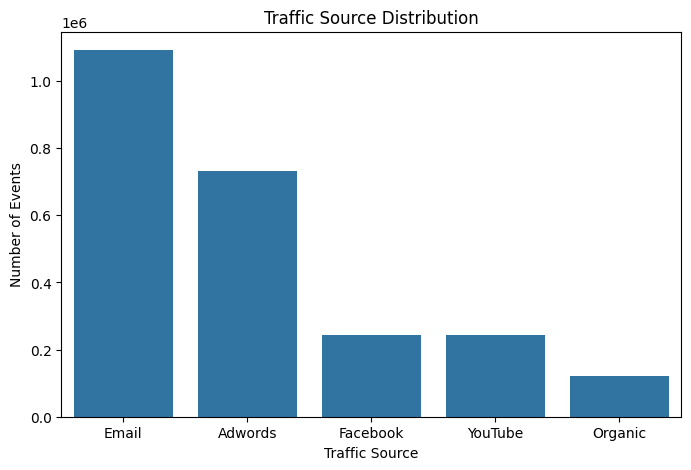

In [ ]:
traffic_counts = df_events_cleaned['traffic_source'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
  x=traffic_counts.index,
  y=traffic_counts.values
)

plt.title('Traffic Source Distribution')
plt.xlabel('Traffic Source')
plt.ylabel('Number of Events')

plt.show()

#### **b. Traffic Source vs Session Engagement**

In [ ]:
df_events_cleaned.groupby('traffic_source')['session_id'].nunique()

,session_id
traffic_source,
Adwords,205010
Email,306313
Facebook,67933
Organic,34301
YouTube,68202


##### **Key Findings**

| Traffic Source | Unique Sessions |
| -------------- | --------------: |
| Email          |         306,313 |
| Adwords        |         205,010 |
| YouTube        |          68,202 |
| Facebook       |          67,933 |
| Organic        |          34,301 |

Pola session distribution hampir identik dengan traffic volume distribution, yang berarti:

- Email dan Adwords tidak hanya menghasilkan event tinggi,
- tetapi juga menghasilkan jumlah session terbesar.

Hal ini mengindikasikan **acquisition channels tersebut benar-benar menjadi penggerak utama platform activity**.

##### **Initial Business Interpretation**

1. Email Menjadi Core Engagement Driver

    Bukan hanya volume event tertinggi, tetapi juga jumlah session tertinggi. Temuan ini memperkuat indikasi bahwa **retention & remarketing strategy memainkan peran besar dalam customer engagement**.

2. Organic Traffic Sangat Rendah Secara Konsisten

    Temuan Organic:

    - event rendah,
    - session rendah.

    Penting diketahui karena **organic ecosystem terlihat underdeveloped**.

    Dari sisi sustainability, ketergantungan besar terhadap:

    - Email,
    - Adwords,

    bisa meningkatkan:

    - acquisition dependency,
    - mendominasi sessions.

3. Paid Channels Mendominasi Customer Activity

    Email + Adwords:

    - mendominasi events,
    - mendominasi sessions.

    Hal ini bisa menjadi **potential efficiency risk**, karena jika paid acquisition efficiency turun, maka engagement platform bisa terdampak signifikan.

##### **Main Insight So Far**

Mulai mendukung narrative utama:

**“business heavily relies on acquisition-driven activity”**.

**Visualization**

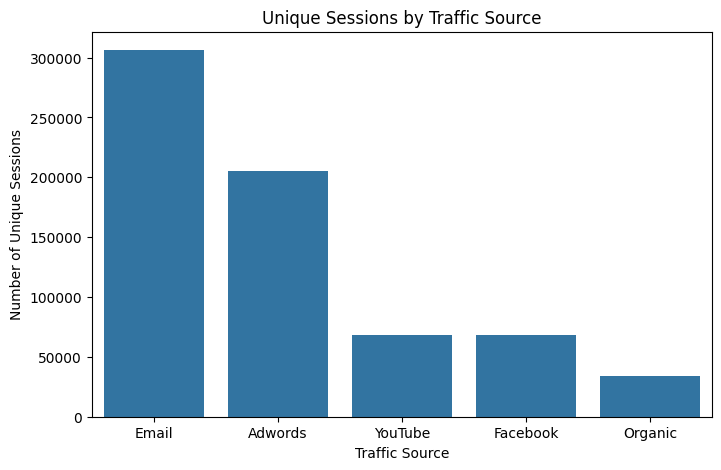

In [ ]:
session_counts = (
  df_events_cleaned.groupby('traffic_source')['session_id']
  .nunique()
  .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
  x=session_counts.index,
  y=session_counts.values
)

plt.title('Unique Sessions by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Number of Unique Sessions')

plt.show()

#### **c. Engagement Intensity Analysis**

In [ ]:
events_per_session = (
  df_events_cleaned.groupby('traffic_source')
  .agg(
    total_events=('id', 'count'),
    total_sessions=('session_id', 'nunique')
  )
)

events_per_session['avg_events_per_session'] = (
  events_per_session['total_events'] /
  events_per_session['total_sessions']
)

events_per_session

,total_events,total_sessions,avg_events_per_session
traffic_source,,,
Adwords,731144,205010,3.566382
Email,1091988,306313,3.564942
Facebook,243834,67933,3.589331
Organic,122059,34301,3.558468
YouTube,242938,68202,3.562036


##### **Key Findings**

| Traffic Source | Avg Events per Session |
| -------------- | ---------------------: |
| Facebook       |                  3.589 |
| Adwords        |                  3.566 |
| Email          |                  3.565 |
| YouTube        |                  3.562 |
| Organic        |                  3.558 |

Meskipun:

- volume traffic sangat berbeda,
- jumlah session sangat berbeda,

ternyata **engagement intensity antar channel hampir identik**. Dimana semua channel berada di rentang **3.56–3.59 events per session**.

##### **Initial Business Interpretation**

1. Traffic Quality Relatif Konsisten Antar Channel

    Hal ini berarti:

    - user dari berbagai source menunjukkan pola activity yang mirip,
    - tidak ada channel yang secara signifikan menghasilkan engagement lebih dalam.

    Temuan ini menarik karena **dominasi Email & Adwords lebih disebabkan oleh volume acquisition, bukan engagement superiority**.

2. Facebook Sedikit Lebih Tinggi

    Walaupun selisihnya kecil, Facebook memiliki **avg events per session tertinggi**. Hal ini mengindikasikan:

    - social traffic sedikit lebih exploratory,
    - atau user behavior lebih interactive.

    Namun **perbedaannya belum cukup besar untuk menjadi strategic differentiator**.

3. Potential Acquisition Efficiency Concern

    Karena:

    - engagement depth hampir sama,
    - tetapi traffic distribution sangat timpang,

    maka **bisnis kemungkinan lebih fokus pada traffic scaling daripada engagement optimization**.

    Temuan ini cukup baik untuk:

    - strategic recommendation nanti,
    - terutama terkait acquisition diversification.

##### **Main Insight So Far**

Sejauh ini:

- Email & Adwords mendominasi activity,
- tetapi tidak menghasilkan engagement intensity yang jauh lebih baik.

Artinya, **channel dominance belum tentu berarti higher engagement quality**.

Temuan ini membuka narrative:

- acquisition dependency,
- tetapi engagement parity.

**Visualization**

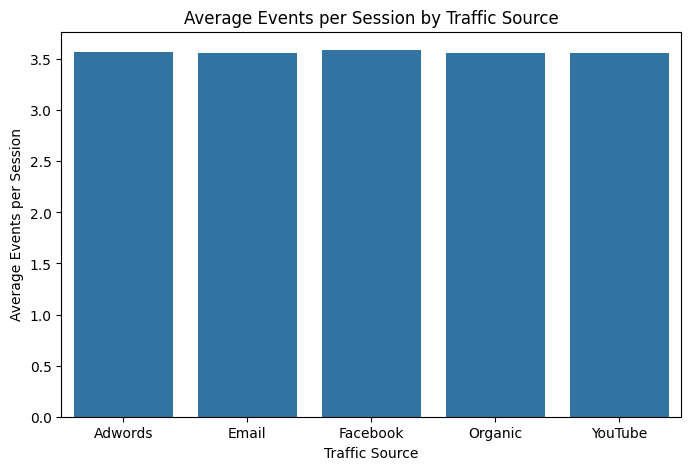

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
  x=events_per_session.index,
  y=events_per_session['avg_events_per_session']
)

plt.title('Average Events per Session by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Average Events per Session')

plt.show()

#### **d. Customer Activity Trend Analysis**

In [ ]:
monthly_events = (
  df_events_cleaned.groupby(['event_year', 'event_month'])
  .size()
  .reset_index(name='total_events')
)

monthly_events

,event_year,event_month,total_events
0,2019,1,18059
1,2019,2,17594
2,2019,3,19801
3,2019,4,19846
4,2019,5,20663
...,...,...,...
56,2023,9,75061
57,2023,10,83393
58,2023,11,89113
59,2023,12,106248


##### **Key Findings**

Data menunjukkan **pertumbuhan customer activity yang sangat konsisten dari 2019 hingga 2024**.

Key Pattern:

- Early Period (2019), aktivitas masih relatif rendah, sekitar 18k–23k events per bulan.
- Mid Growth Period (2021–2022), aktivitas meningkat menjadi sekitar 30k–50k.
- High Growth Period (2023–2024), aktivitas melonjak menjadi 75k-106k events per bulan.

Aktivitas customer meningkat hampir 5–6x dibanding awal periode, dari 18k menjadi 100k events. Hal ini menunjukkan **ecommerce platform mengalami pertumbuhan engagement yang sangat signifikan**.

##### **Initial Business Interpretation**

1. Platform Growth Sangat Kuat

    Peningkatan activity yang konsisten mengindikasikan:

    - customer engagement meningkat,
    - acquisition scale bertumbuh,
    - dan platform adoption semakin besar.

    Hal ini merupakan **sinyal positif untuk business expansion**.

2. Acceleration Semakin Agresif di 2023

    Pertumbuhan terlihat semakin eksponensial pada 2023, khususnya Q3 dan Q4 2023. Hal ini dapat mengindikasikan:

    - scaling acquisition strategy,
    - peningkatan marketing activity,
    - seasonal demand surge,
    - atau peningkatan retention effectiveness.

3. Potential Operational Risk

    Hal ini penting, karena jika activity meningkat drastis, maka **pressure terhadap fulfillment dan operational capacity juga meningkat**.

    Dan ini mulai **menghubungkan acquisition growth dengan potential operational inefficiency**.

    Dimana temuan ini sesuai dengan main narrative.

4. Q4 Seasonality Indication

    Terlihat:

    - Oct–Dec consistently tinggi.

    Hal ini mengindikasikan kemungkinan seasonal ecommerce spikes, yang sangat bagus untuk:

    - dashboard trend,
    - strategic insight,
    - business recommendation.

**Visualization**

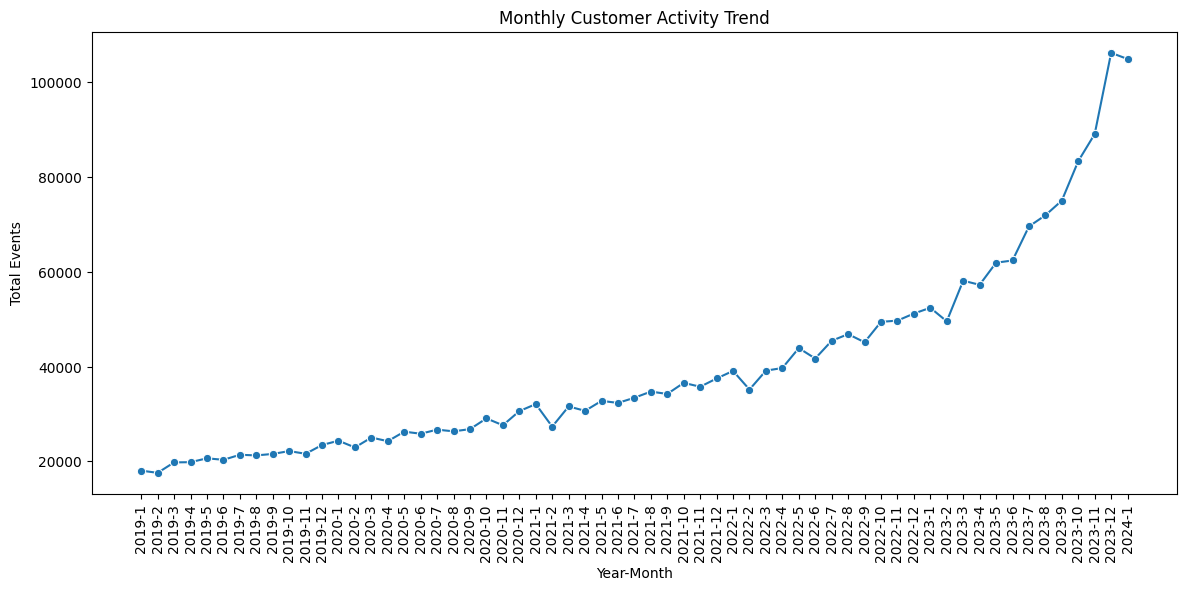

In [ ]:
monthly_events['year_month'] = (
  monthly_events['event_year'].astype(str) +
  '-' +
  monthly_events['event_month'].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
  data=monthly_events,
  x='year_month',
  y='total_events',
  marker='o'
)

plt.xticks(rotation=90)

plt.title('Monthly Customer Activity Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Events')

plt.show()

**Main narrative so far**

Customer activity terus meningkat secara signifikan, namun pertumbuhan tersebut berpotensi meningkatkan tekanan terhadap operational fulfillment dan memperbesar risiko revenue leakage apabila efisiensi bisnis tidak berkembang secara seimbang.

#### **e. Customer Activity by Hour**

In [ ]:
df_events_cleaned['event_hour'].value_counts().sort_index()

,count
event_hour,
0,102664
1,127670
2,124750
3,126869
4,126076
5,126812
6,128493
7,130242
8,128164


##### **Key Findings**

Aktivitas customer:

- relatif stabil dari dini hari hingga siang,
- mulai menurun sore hari,
- dan turun drastis pada malam hari tertentu.

**Peak Activity Window**

Jam dengan aktivitas tertinggi berada di **sekitar 06:00–11:00**.

Dengan activity: ±128k–130k events.

Hal ini menunjukkan **customer activity sangat aktif pada pagi hingga menjelang siang**.

**Sharp Decline**

Aktivitas mulai turun signifikan setelah jam 15:00 dan sangat rendah pada 19:00–21:00, terutama **jam 20:00 menjadi titik terendah ekstrem**.

##### **Initial Business Interpretation**

1. Customer Engagement Sangat Time-Dependent

    Hal ini menunjukkan **customer behavior memiliki pola temporal yang kuat**. Artinya:

    - waktu campaign,
    - email marketing,
    - notification timing,
    - dan advertising scheduling

    kemungkinan **sangat memengaruhi engagement performance**.

2. Morning–Midday Menjadi Prime Engagement Window

    Karena activity tertinggi konsisten terjadi pagi hingga menjelang siang. Temuan ini dapat menjadi strategic timing insight untuk:

    - campaign deployment,
    - promotional push,
    - traffic acquisition optimization.

3. Malam Hari Memiliki Engagement Sangat Rendah

    Khususnya 19:00–21:00. Cukup menarik karena banyak ecommerce yang biasanya aktif pada malam hari. Artinya, kemungkinan:

    - target audience berbeda,
    - atau traffic ecosystem platform memiliki karakteristik khusus.

4. Potential Operational Implication

    Karena peak activity terjadi pagi–siang, maka **order inflow kemungkinan terkonsentrasi pada jam tersebut**.

    Temuan ini nanti bisa dikaitkan dengan;

    - fulfillment load,
    - operational bottleneck,
    - shipping delay analysis.

**Visualisasi**

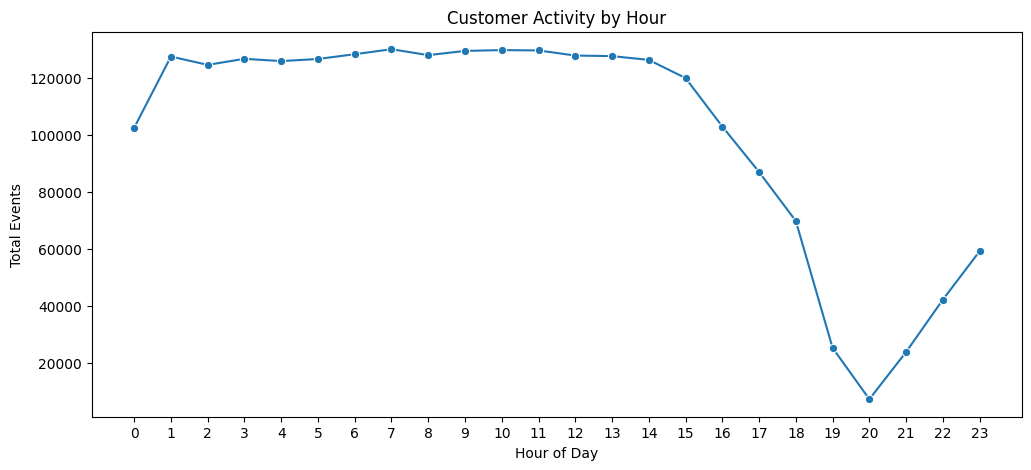

In [ ]:
hourly_activity = (
  df_events_cleaned['event_hour']
  .value_counts()
  .sort_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
  x=hourly_activity.index,
  y=hourly_activity.values,
  marker='o'
)

plt.title('Customer Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Events')

plt.xticks(range(0,24))

plt.show()

#### **f. Conversion Efficiency by Traffic Source**

In [ ]:
df_events_cleaned['event_type'].value_counts()

,count
event_type,
product,845607
cart,595994
department,595323
purchase,181759
cancel,125568
home,87712


In [ ]:
traffic_conversion = (
  df_events_cleaned
  .groupby('traffic_source')
  .agg(
    total_events=('id', 'count'),
    purchase_events=(
      'event_type',
      lambda x: (x == 'purchase').sum()
    )
  )
  .reset_index()
)

traffic_conversion['conversion_rate_pct'] = (
  traffic_conversion['purchase_events'] /
  traffic_conversion['total_events']
) * 100

traffic_conversion.sort_values(
  by='conversion_rate_pct',
  ascending=False
)

,traffic_source,total_events,purchase_events,conversion_rate_pct
2,Facebook,243834,18305,7.507157
1,Email,1091988,81706,7.482317
3,Organic,122059,9124,7.475074
0,Adwords,731144,54542,7.459816
4,YouTube,242938,18082,7.443051


##### **Key Findings**

| Traffic Source | Conversion Rate |
| -------------- | --------------: |
| Facebook       |          ~7.51% |
| Email          |          ~7.48% |
| Organic        |          ~7.48% |
| Adwords        |          ~7.46% |
| YouTube        |          ~7.44% |

Perbedaan conversion rate antar traffic source sangat kecil. Walaupun:

- Email dan Adwords mendominasi total traffic,
- Organic memiliki volume jauh lebih kecil,

**seluruh traffic source menghasilkan conversion rate yang hampir identik (~7.4–7.5%)**.

##### **Initial Business Interpretation**

1. Dominasi Traffic Lebih Dipengaruhi Volume Acquisition daripada Conversion Efficiency

    Email dan Adwords menghasilkan traffic terbesar, tetapi **tidak memiliki conversion efficiency yang jauh lebih baik dibanding channel lain**.

    Artinya, **dominasi traffic kemungkinan lebih disebabkan oleh acquisition scale daripada superior conversion quality**.

2. Organic Traffic Menunjukkan Conversion Quality yang Kompetitif

    Walaupun Organic hanya menyumbang ~5% total traffic, conversion rate-nya **hampir setara dengan channel utama lainnya**.

    Hal ini menunjukkan:

    - kualitas user intent Organic kemungkinan cukup baik,
    - dan Organic berpotensi menjadi growth opportunity yang belum dimaksimalkan.

3. Tidak Ada Major Conversion Inefficiency Antar Channel

    Karena conversion rate antar source **sangat homogen**, mengindikasikan bahwa:

    - customer journey antar channel relatif konsisten,
    - dan tidak ada traffic source yang sangat underperform secara conversion.

4. Potential Overdependency Risk Tetap Ada

    Walaupun conversion efficiency relatif sama, **bisnis tetap sangat bergantung pada Email dan Adwords untuk acquisition volume**.

    Hal ini berarti:

    - acquisition diversification masih menjadi opportunity penting,
    - terutama untuk mengurangi dependency risk.

**Visualization**

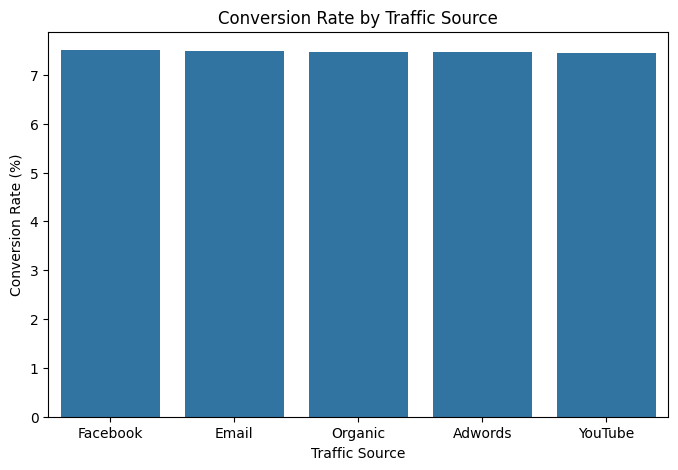

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
  data=traffic_conversion.sort_values(
    by='conversion_rate_pct',
    ascending=False
  ),
  x='traffic_source',
  y='conversion_rate_pct'
)

plt.title('Conversion Rate by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Conversion Rate (%)')

plt.show()

#### **f. Kesimpulan Insight**

**Customer Growth & Acquisition Dependency**

1. **Ecommerce traffic didominasi oleh Email dan Adwords**

    Email dan Adwords menyumbang hampir 75% total customer activity dan session, menunjukkan bahwa platform sangat bergantung pada acquisition-driven traffic dan direct marketing channels.

2. **Organic traffic contribution masih sangat rendah**

    Organic traffic hanya berkontribusi sekitar 5% terhadap total activity, mengindikasikan bahwa bisnis masih memiliki ketergantungan tinggi terhadap paid acquisition dan retention-based marketing.

3. **Engagement intensity relatif konsisten antar traffic source**

    Rata-rata events per session pada seluruh traffic source berada pada kisaran yang hampir sama (~3.56 events/session), menunjukkan bahwa dominasi traffic channel lebih dipengaruhi oleh volume acquisition dibanding kualitas engagement yang berbeda secara signifikan.

4. **Customer activity mengalami pertumbuhan sangat signifikan**

    Jumlah customer events meningkat secara konsisten dari sekitar 18 ribu events per bulan pada 2019 menjadi lebih dari 100 ribu events pada awal 2024, mengindikasikan pertumbuhan engagement dan platform adoption yang sangat kuat.

5. **Aktivitas customer terkonsentrasi pada pagi hingga siang hari**

    Customer activity mencapai puncak pada rentang waktu 06:00–11:00 dan mengalami penurunan signifikan pada malam hari, menunjukkan adanya pola temporal behavior yang dapat dimanfaatkan untuk optimasi campaign timing dan operational planning.

6. **Conversion efficiency antar traffic source relatif homogen**

    Meskipun Email dan Adwords mendominasi total customer activity, seluruh traffic source menunjukkan conversion rate yang hampir identik pada kisaran sekitar 7.4–7.5%. Hal ini menunjukkan bahwa dominasi traffic lebih dipengaruhi oleh volume acquisition dibanding perbedaan kualitas conversion antar channel.

### 3.2 Sales & Product Performance

#### **a. Monthly Revenue Trend Analysis**

In [ ]:
monthly_revenue = (
  df_order_items_cleaned
  .groupby(['order_year', 'order_month'])['sale_price']
  .sum()
  .reset_index()
)

monthly_revenue.rename(
  columns={'sale_price': 'total_revenue'},
  inplace=True
)

monthly_revenue

,order_year,order_month,total_revenue
0,2019,1,1965.080007
1,2019,2,4015.890006
2,2019,3,8088.340017
3,2019,4,9104.450037
4,2019,5,16128.430004
...,...,...,...
56,2023,9,481772.300609
57,2023,10,544430.900469
58,2023,11,582231.620540
59,2023,12,720588.810540


##### **Key Findings**

Revenue menunjukkan **pertumbuhan yang sangat agresif dan konsisten dari 2019 hingga 2024**.

**Revenue Growth Observation**

- Early Period (2019), revenue bulanan sekitar 2k–38k.
- Growth Expansion (2020–2022), revenue meningkat menjadi sekitar 40k–260k per bulan.
- Hyper Growth Period (2023–2024), revenue melonjak menjadi 300k–824k per bulan.

##### **Initial Business Interpretation**

1. Customer Growth Berhasil Dikonversi Menjadi Revenue Growth

    Pada 3.1, sudah terlihat bahwa:

    - customer activity meningkat drastis.

    Sekarang:

    - revenue juga meningkat sangat agresif.

    Artinya, **platform tidak hanya berhasil meningkatkan engagement, tetapi juga monetization**.

2. Revenue Growth Semakin Eksponensial Setelah 2022

    Pertumbuhan terlihat semakin accelerating pada 2023, terutama Q3 dan Q4 2023. Hal ini menunjukkan:

    - business scaling,
    - kemungkinan acquisition expansion,
    - dan peningkatan transaction volume yang signifikan.

3. Strong Seasonality Signal

    Q4 consistently menjadi peak revenue period. Terutama Oct-Dec.

    Dan Desember 2023 menjadi **revenue peak terbesar sebelum 2024**.

    Typical ecommerce behavior, bagus untuk:

    - operational planning,
    - campaign strategy,
    - inventory preparation.

4. Potential Operational Pressure

    Karena pertumbuhan revenue yang sangat cepat, **kemungkinan meningkatkan tekanan pada fulfillment operations**.

    Dan ini akan menjadi **bridge menuju section operational analysis**.

**Visualization**

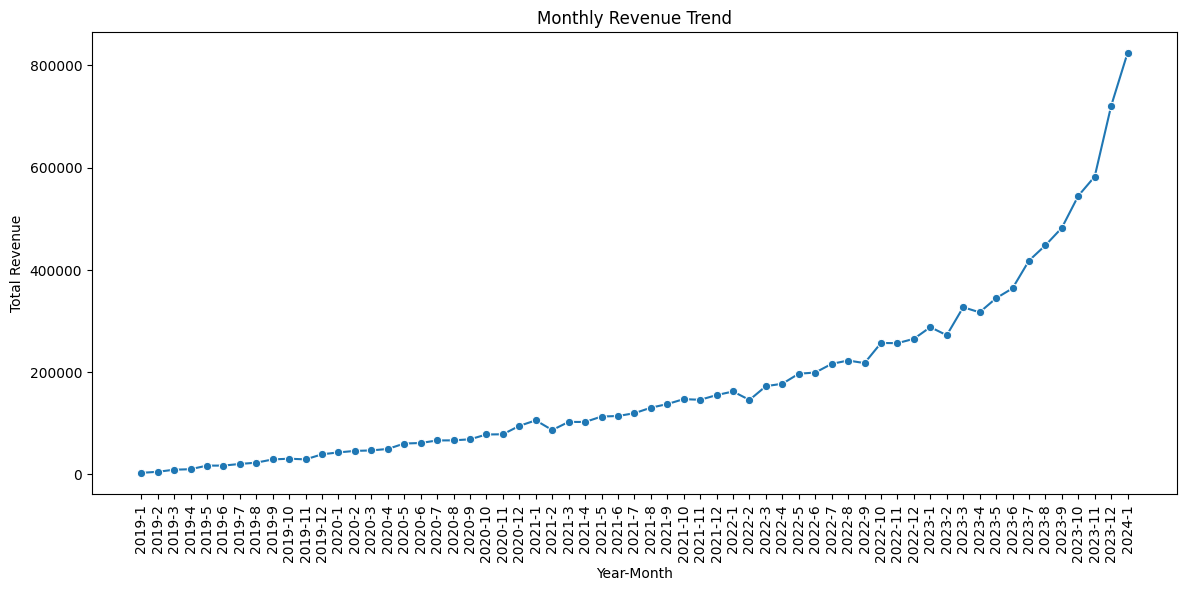

In [ ]:
monthly_revenue['year_month'] = (
  monthly_revenue['order_year'].astype(str) +
  '-' +
  monthly_revenue['order_month'].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
  data=monthly_revenue,
  x='year_month',
  y='total_revenue',
  marker='o'
)

plt.xticks(rotation=90)

plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')

plt.show()

#### **b. Revenue Contribution by Product Category**

In [ ]:
category_revenue = (
  df_order_items_cleaned
  .merge(
    df_products_cleaned,
    left_on='product_id',
    right_on='id',
    how='left'
  )
  .groupby('category')['sale_price']
  .sum()
  .sort_values(ascending=False)
  .reset_index()
)

category_revenue.rename(
  columns={'sale_price': 'total_revenue'},
  inplace=True
)

category_revenue.head(10)

,category,total_revenue
0,Outerwear & Coats,1.301571e+06
1,Jeans,1.253644e+06
2,Sweaters,8.426515e+05
3,Suits & Sport Coats,6.667673e+05
4,Fashion Hoodies & Sweatshirts,6.493528e+05
5,Swim,6.467387e+05
6,Sleep & Lounge,5.373921e+05
7,Shorts,5.120695e+05
8,Tops & Tees,4.915514e+05
9,Dresses,4.644168e+05


##### **Key Findings**

| Category                      | Revenue Contribution |
| ----------------------------- | -------------------: |
| Outerwear & Coats             |               ~1.30M |
| Jeans                         |               ~1.25M |
| Sweaters                      |                ~842K |
| Suits & Sport Coats           |                ~667K |
| Fashion Hoodies & Sweatshirts |                ~649K |

Revenue sangat terkonsentrasi pada apparel core categories.

Kategori:

- Outerwear & Coats
- Jeans
- Sweaters

menjadi kontribusi terbesar. Temuan ini menunjukkan bahwa **fashion essentials menjadi revenue backbone bisnis**.

##### **Initial Business Interpretation**

1. Product Portfolio Memiliki Revenue Concentration

    Revenue tidak tersebar merata, sebagian besar revenue **terkonsentrasi pada beberapa kategori utama**.

    Temuan ini penting karena:

    - category dependency meningkat,
    - business risk menjadi lebih tinggi jika demand category utama menurun.

2. Outerwear & Coats Menjadi Revenue Driver Utama

    Kategori ini menghasilkan **revenue tertinggi secara keseluruhan.** Kemungkinan:

    - ASP (average selling price) lebih tinggi,
    - purchase value lebih besar,
    - atau demand category sangat kuat.

    Hal ini dapat dikaitkan dengan:

    - profitability,
    - return behavior,
    - fulfillment complexity.

3. Revenue Drivers Didominasi High-Value Fashion Categories

    Kategori revenue tertinggi cenderung premium/fashion-heavy, yang menunjukkan bahwa **monetization platform kemungkinan lebih ditopang oleh high-value apparel daripada low-ticket items**.

4. Potential Business Risk — Revenue Dependency

    Karena revenue terkonsentrasi, **bisnis berpotensi rentan terhadap category-specific demand fluctuation**.

**Visualization**

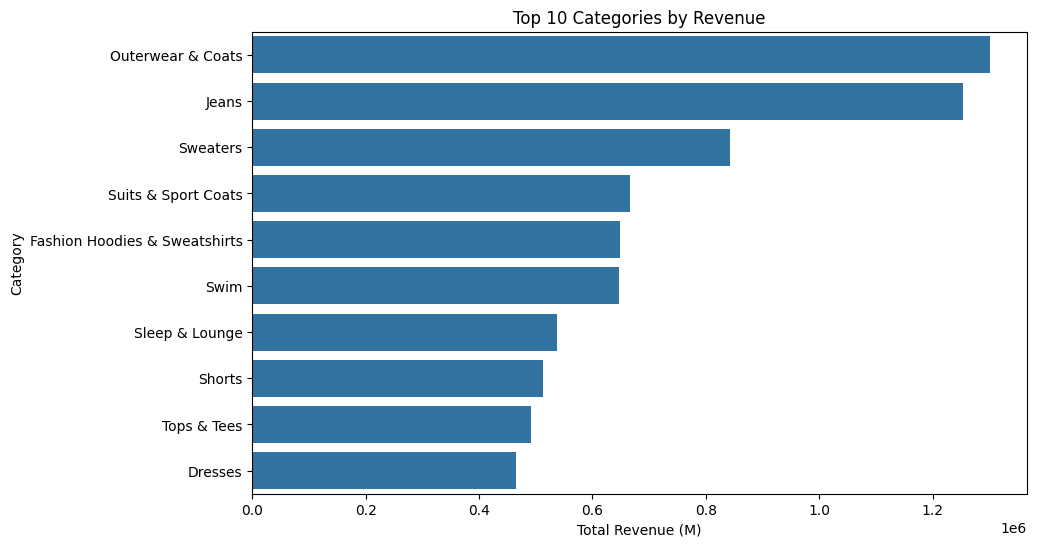

In [ ]:
top_categories = category_revenue.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_categories,
  y='category',
  x='total_revenue'
)

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Total Revenue (M)')
plt.ylabel('Category')

plt.show()

#### **c. Profitability by Product Category**

In [ ]:
category_profit = (
  df_order_items_cleaned
    .merge(
      df_products_cleaned,
      left_on='product_id',
      right_on='id',
      how='left'
    )
)

category_profit['profit'] = (
  category_profit['sale_price'] -
  category_profit['cost']
)

category_profit_summary = (
  category_profit
  .groupby('category')
  .agg(
    total_revenue=('sale_price', 'sum'),
    total_profit=('profit', 'sum')
  )
  .sort_values(by='total_profit', ascending=False)
  .reset_index()
)

category_profit_summary.head(10)

,category,total_revenue,total_profit
0,Outerwear & Coats,1.301571e+06,721875.075552
1,Jeans,1.253644e+06,582912.002207
2,Sweaters,8.426515e+05,437260.450999
3,Suits & Sport Coats,6.667673e+05,398930.048650
4,Swim,6.467387e+05,316596.397142
5,Fashion Hoodies & Sweatshirts,6.493528e+05,312268.251792
6,Sleep & Lounge,5.373921e+05,277012.735385
7,Active,4.642634e+05,270137.246519
8,Shorts,5.120695e+05,255751.936677
9,Dresses,4.644168e+05,254917.227952


##### **Key Findings**

| Category            | Revenue | Profit |
| ------------------- | ------: | -----: |
| Outerwear & Coats   |  ~1.30M |  ~722K |
| Jeans               |  ~1.25M |  ~583K |
| Sweaters            |   ~843K |  ~437K |
| Suits & Sport Coats |   ~667K |  ~399K |
| Swim                |   ~647K |  ~317K |

Revenue leaders juga menjadi profit leaders, dimana kategori:

- Outerwear & Coats
- Jeans
- Sweaters

tidak hanya menghasilkan revenue tinggi namun juga profit contribution terbesar. Temuan ini menunjukkan **revenue growth bisnis masih berkualitas baik secara profitabilitas**.

##### **Initial Business Interpretation**

1. Outerwear & Coats Menjadi Strategic Product Category

    Kategori ini memiliki revenue tertinggi sekaligus profit tertinggi, artinya kategori ini **kemungkinan merupakan core business driver platform**.

    Hal ini penting diketahui untuk:

    - inventory prioritization,
    - campaign strategy,
    - fulfillment planning.

2. High-Value Fashion Categories Mendominasi Profitability

    Kategori fashion premium:

    - coats,
    - suits,
    - sweaters,
    - jeans

    menjadi **profit engine utama bisnis**.

    Temuan ini menunjukkan bahwa **platform tidak hanya mengandalkan volume tetapi juga monetization efficiency**.

3. Revenue Growth Masih Healthy

    Informasi penting karena, terkadang revenue tinggi namun tidak profitable atau margin terlalu tipis. Namun di sini, ditemukan bahwa **revenue dan profit masih bergerak searah**.

    Artinya, **business scaling sejauh ini masih cukup sustainable**.

**Visualization**

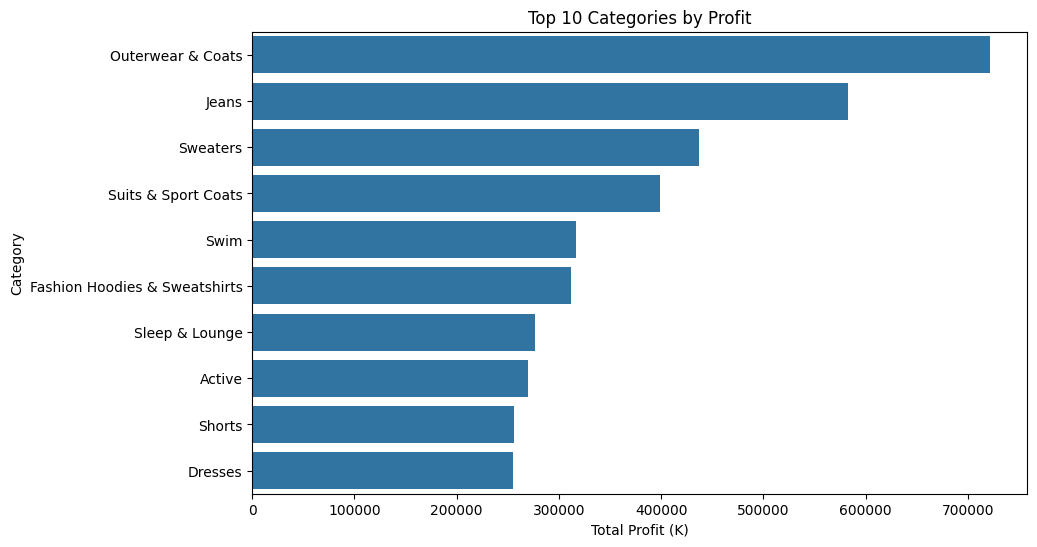

In [ ]:
top_profit_categories = (
  category_profit_summary.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_profit_categories,
  y='category',
  x='total_profit'
)

plt.title('Top 10 Categories by Profit')
plt.xlabel('Total Profit (K)')
plt.ylabel('Category')

plt.show()

#### **d. Profit Margin Efficiency Analysis**

In [ ]:
category_profit_summary['profit_margin_pct'] = (
  (category_profit_summary['total_profit'] /
   category_profit_summary['total_revenue']) * 100
)

category_profit_summary.sort_values(
  by='profit_margin_pct',
  ascending=False
).head(10)

,category,total_revenue,total_profit,profit_margin_pct
14,Blazers & Jackets,2.918678e+05,181379.038838,62.144242
19,Skirts,1.156185e+05,69367.242900,59.996648
22,Socks & Hosiery,6.340313e+04,37994.721623,59.925625
10,Accessories,4.178664e+05,250189.657921,59.873125
3,Suits & Sport Coats,6.667673e+05,398930.048650,59.830475
7,Active,4.642634e+05,270137.246519,58.186210
15,Maternity,2.657458e+05,148312.282145,55.809840
0,Outerwear & Coats,1.301571e+06,721875.075552,55.461840
9,Dresses,4.644168e+05,254917.227952,54.889747
11,Pants,4.366047e+05,236164.650834,54.091180


##### **Key Findings**

| Category            | Profit Margin % |
| ------------------- | --------------: |
| Blazers & Jackets   |          62.14% |
| Skirts              |          60.00% |
| Socks & Hosiery     |          59.93% |
| Accessories         |          59.87% |
| Suits & Sport Coats |          59.83% |

High-Revenue Categories Tidak Selalu Margin Leaders.

Walaupun Outerwear & Coats memiliki profit terbesar, ternyata margin tertinggi dimiliki kategori lain seperti:

- Blazers & Jackets,
- Skirts,
- Accessories.

Temuan ini sangat penting, karena **revenue scale ≠ margin efficiency**.

##### **Initial Business Interpretation**

1. Blazers & Jackets Menjadi Most Efficient Monetization Category

    Dengan **>62% profit margin**, kategori ini menunjukkan:

    - monetization efficiency sangat tinggi,
    - kemungkinan pricing power kuat,
    - atau operational/product cost relatif efisien.

    Temuan ini bisa menjadi **strategic growth opportunity**.

2. Outerwear & Coats Tetap Strong Secara Absolute & Relative

    Hal ini penting karena kategori ini:

    - memiliki revenue tertinggi,
    - profit tertinggi,
    - margin sehat (~55%).

    Yang berarti, kategori ini benar-benar menjadi strategic backbone bisnis.

3. Revenue Growth Bisnis Masih Berkualitas Tinggi

    Karena kategori tertinggi tidak hanya high revenue tetapi juga high margin, mengindikasikan bahwa **business scaling masih profitable dan sehat**.

**Visualization**

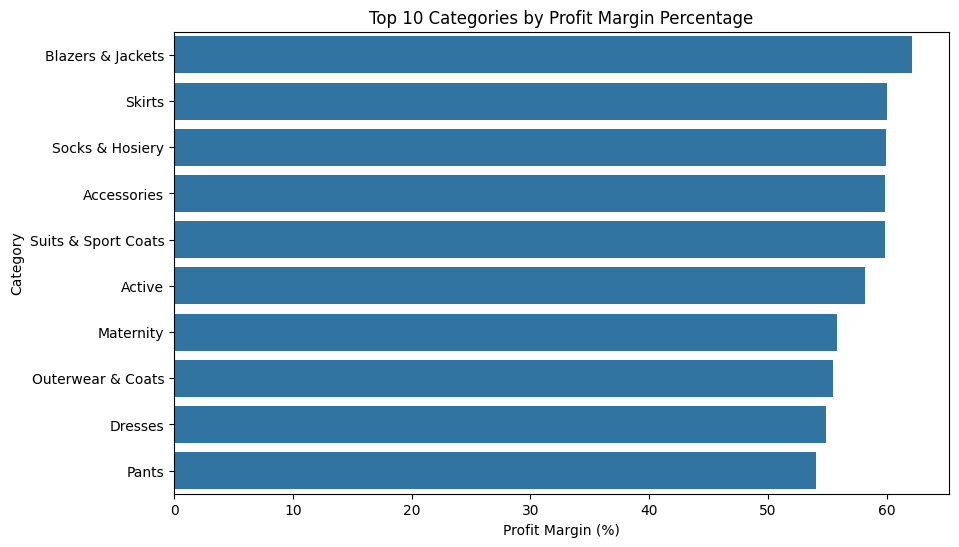

In [ ]:
top_margin_categories = (
  category_profit_summary
  .sort_values(by='profit_margin_pct', ascending=False)
  .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_margin_categories,
  y='category',
  x='profit_margin_pct'
)

plt.title('Top 10 Categories by Profit Margin Percentage')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')

plt.show()

#### **e. Return Rate by Product Category**

In [ ]:
category_returns = (
  df_order_items_cleaned
    .merge(
      df_products_cleaned,
      left_on='product_id',
      right_on='id',
      how='left'
    )
    .groupby('category')
    .agg(
      total_items=('id_x', 'count'),
      returned_items=('is_returned', 'sum')
    )
    .reset_index()
)

category_returns['return_rate_pct'] = (
  (category_returns['returned_items'] /
   category_returns['total_items']) * 100
)

category_returns.sort_values(
  by='return_rate_pct',
  ascending=False
).head(10)

,category,total_items,returned_items,return_rate_pct
8,Jumpsuits & Rompers,934,106,11.349036
20,Suits,1024,110,10.742188
21,Suits & Sport Coats,5223,555,10.626077
12,Pants,7328,772,10.534934
1,Active,9086,947,10.422628
14,Plus,4323,448,10.363174
15,Shorts,11038,1139,10.318898
10,Maternity,5165,530,10.261375
11,Outerwear & Coats,8968,919,10.247547
5,Fashion Hoodies & Sweatshirts,11885,1217,10.239798


##### **Key Findings**

| Category            | Return Rate |
| ------------------- | ----------: |
| Jumpsuits & Rompers |      11.35% |
| Suits               |      10.74% |
| Suits & Sport Coats |      10.63% |
| Pants               |      10.53% |
| Active              |      10.42% |

High-value fashion categories memiliki return rate tinggi.

Kategori seperti:

- Suits,
- Suits & Sport Coats,
- Outerwear & Coats,
- Fashion Hoodies & Sweatshirts

memiliki **return rate >10%**.

Temuan ini penting karena beberapa kategori tersebut sebelumnya juga **menjadi revenue & profit drivers utama**.

##### **Initial Business Interpretation**

1. Revenue Drivers Juga Menjadi Revenue Leakage Risks

    Kategori yang menghasilkan revenue terbesar serta profit tinggi, juga **memiliki return rate tinggi**.

    Artinya, **sebagian business growth berpotensi terkikis oleh return behavior**.

2. Fashion-Fit Complexity Kemungkinan Memengaruhi Return Rate

    Kategori:

    - suits,
    - pants,
    - outerwear,
    - jumpsuits

    cenderung **size-sensitive dan fit-sensitive**.

    Hal ini bisa menjadi indikasi:

    - sizing issue,
    - expectation mismatch,
    - atau product fit inconsistency.

3. Profitability Tidak Bisa Dilihat Tanpa Return Context

    Sebelumnya, beberapa kategori terlihat sangat profitable. Namun sekareang, **return rate menunjukkan hidden operational & revenue risk**.

4. Potential Operational & Fulfillment Impact

    Return tinggi juga bisa berarti:

    - reverse logistics cost,
    - operational burden,
    - customer dissatisfaction risk.

    Temuan ini akan menjadi **bridge menuju operational analysis**.

**Visualization**

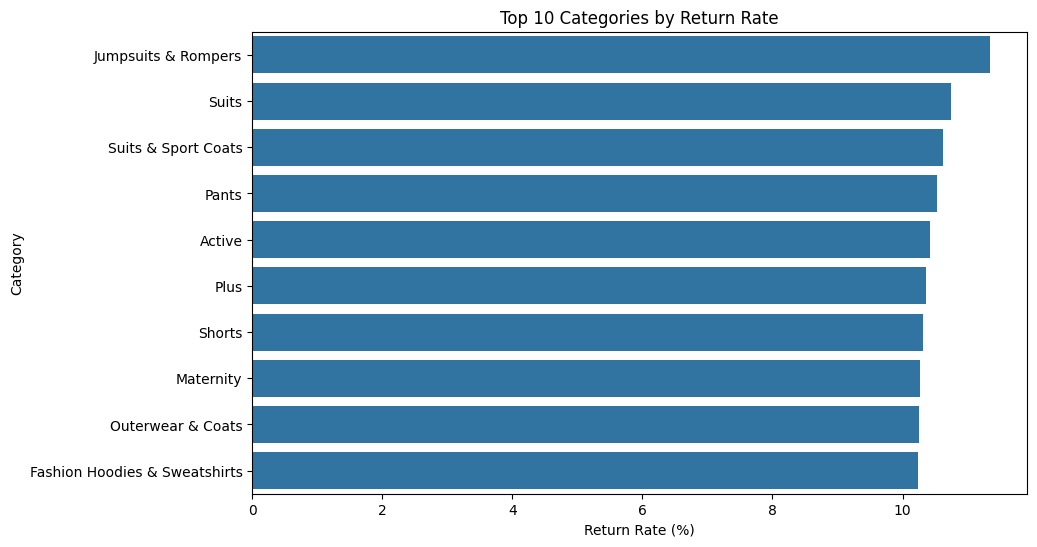

In [ ]:
top_return_categories = (
  category_returns
  .sort_values(by='return_rate_pct', ascending=False)
  .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_return_categories,
  y='category',
  x='return_rate_pct'
)

plt.title('Top 10 Categories by Return Rate')
plt.xlabel('Return Rate (%)')
plt.ylabel('Category')

plt.show()

#### **f. Kesimpulan Insight**

**Revenue Growth, Profitability, dan Leakage Risk**

1. **Revenue bisnis mengalami pertumbuhan yang sangat signifikan**

    Total revenue meningkat secara konsisten dari sekitar 2 ribu pada awal 2019 menjadi lebih dari 824 ribu pada awal 2024. Hal ini menunjukkan bahwa platform berhasil mengubah pertumbuhan customer activity menjadi pertumbuhan monetisasi yang sangat agresif.

2. **Revenue bisnis terkonsentrasi pada beberapa kategori utama**

    Kategori seperti Outerwear & Coats, Jeans, dan Sweaters menjadi kontributor revenue terbesar dalam platform. Hal ini menunjukkan bahwa bisnis memiliki ketergantungan cukup tinggi terhadap core apparel categories sebagai penggerak utama revenue.

3. **Kategori dengan revenue tinggi juga menghasilkan profit yang tinggi**

    Outerwear & Coats, Jeans, dan Sweaters tidak hanya menjadi top revenue contributors, tetapi juga menghasilkan total profit terbesar. Hal ini menunjukkan bahwa pertumbuhan revenue bisnis sejauh ini masih didukung oleh performa profitabilitas yang sehat.

4. **Profit margin antar kategori menunjukkan tingkat efisiensi monetisasi yang berbeda**

    Kategori seperti Blazers & Jackets, Accessories, dan Suits & Sport Coats memiliki profit margin tertinggi, mengindikasikan bahwa beberapa kategori memiliki monetization efficiency yang lebih baik meskipun tidak selalu menjadi kontributor revenue terbesar.

5. **Beberapa kategori profit driver juga memiliki return rate yang tinggi**

    Kategori seperti Suits & Sport Coats, Outerwear & Coats, Pants, dan Fashion Hoodies & Sweatshirts menunjukkan return rate di atas 10%, meskipun sebelumnya menjadi kontributor revenue dan profit utama. Hal ini mengindikasikan adanya potensi revenue leakage akibat tingginya product return pada kategori fashion tertentu.

6. **Return behavior berpotensi dipengaruhi oleh karakteristik produk fashion**

    Kategori dengan return rate tinggi didominasi oleh produk yang bersifat size-sensitive dan fit-sensitive seperti suits, pants, outerwear, dan jumpsuits. Hal ini mengindikasikan bahwa sizing mismatch, customer expectation gap, atau product fit inconsistency dapat menjadi faktor utama tingginya return behavior.

### 3.3 Fulfillment & Operational Analysis

#### **a. Fulfillment Duration Overview**

In [ ]:
df_order_items_cleaned['fulfillment_duration_days'].describe()

,fulfillment_duration_days
count,63841.000000
mean,2.545950
std,2.221595
min,-4.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,8.000000


##### **Key Findings**

| Metric                    |      Value |
| ------------------------- | ---------: |
| Mean Fulfillment Duration | ~2.55 hari |
| Median                    |     3 hari |
| 75th Percentile           |     4 hari |
| Maximum                   |     8 hari |
| Minimum                   | -4 hari ⚠️ |

Terdapat fulfillment duration negatif.

Minimum value: **-4 hari**

Secara logika bisnis, hal ini tidak mungkin terjadi, karena tidak mungkin delievered sebelum created.

Bukan insight bisnis namun anomali pada data.

**Filter Negative Fulfillment Duration**

In [ ]:
df_order_items_cleaned = df_order_items_cleaned[
  df_order_items_cleaned['fulfillment_duration_days'] >= 0
]

In [ ]:
df_order_items_cleaned['fulfillment_duration_days'].describe()

,fulfillment_duration_days
count,57742.000000
mean,2.990388
std,1.822522
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,8.000000


##### **Key Findings**

| Metric                    |   Value |
| ------------------------- | ------: |
| Mean Fulfillment Duration | ~3 hari |
| Median                    |  3 hari |
| 75th Percentile           |  4 hari |
| Maximum                   |  8 hari |
| Minimum                   |  0 hari |

Fulfillment process relatif cepat dan konsisten.

Mayoritas order selesai dalam 2–4 hari, dengan:

- median 3 hari,
- dan standard deviation relatif rendah.

Hal ini menunjukkan bahwa **fulfillment operations secara umum cukup stabil**.

##### **Initial Business Interpretation**

1. Operational Efficiency Relatif Baik

    Karena fulfillment duration tidak terlalu panjang dan distribusi juga cukup rapat, maka mengindikasikan bahwa **operational workflow masih cukup efficient meskipun business growth meningkat tajam**.

2. Fulfillment Variability Masih Terkontrol

    Maximum 8 hari tetapi 75% order selesai ≤4 hari.

    Artinya, **sebagian besar customer experience kemungkinan masih cukup konsisten**.

3. Scalability Signal Masih Positif

    Karena pada 3.1 dan 3.2:

    - customer activity meningkat drastis,
    - revenue meningkat drastis.

    Namun, **fulfillment duration belum menunjukkan degradation yang ekstrem**.

4. Potential Operational Edge

    Fulfillment cepat:

    - dapat meningkatkan customer satisfaction,
    - mengurangi cancellation risk,
    - dan membantu retention.

**Visualization**

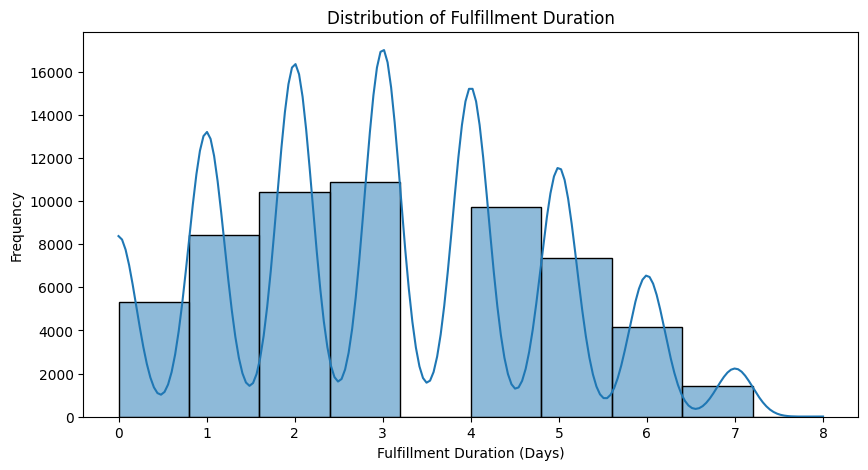

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
  df_order_items_cleaned['fulfillment_duration_days'],
  bins=10,
  kde=True
)

plt.title('Distribution of Fulfillment Duration')
plt.xlabel('Fulfillment Duration (Days)')
plt.ylabel('Frequency')

plt.show()

#### **b. Fulfillment Trend Over Time**

In [ ]:
monthly_fulfillment = (
  df_order_items_cleaned
  .groupby(['order_year', 'order_month'])['fulfillment_duration_days']
  .mean()
  .reset_index()
)

monthly_fulfillment.rename(
  columns={
    'fulfillment_duration_days':
    'avg_fulfillment_duration'
  }, inplace=True
)

monthly_fulfillment

,order_year,order_month,avg_fulfillment_duration
0,2019,1,3.000000
1,2019,2,3.266667
2,2019,3,3.133333
3,2019,4,3.285714
4,2019,5,2.890110
...,...,...,...
56,2023,9,3.045651
57,2023,10,3.000356
58,2023,11,2.988872
59,2023,12,2.988971


##### **Key Findings**

| Observation                  | Result                    |
| ---------------------------- | ------------------------- |
| Average fulfillment duration | stabil di sekitar 3 hari  |
| Variability                  | sangat rendah             |
| Long-term degradation        | tidak terlihat signifikan |
| Growth vs Operations         | relatif balanced          |

Fulfillment performance tetap stabil meskipun business growth meningkat drastis.

Hal ini penting, karena:

- customer activity meningkat berkali-kali lipat,
- revenue meningkat sangat agresif,

tetapi **average fulfillment duration tetap konsisten sekitar 3 hari sepanjang periode dataset**.

##### **Initial Business Interpretation**

1. Operational Scalability Sangat Baik

    Banyak ecommerce mengalami:

    - shipping slowdown,
    - fulfillment bottleneck,
    - operational degradation

    saat scale meningkat.

    Namun di kasus ini, **fulfillment efficiency tetap stabil**.

    Temuan ini menunjukkan bahwa:

    - operational process cukup scalable,
    - fulfillment capacity kemungkinan berkembang seiring growth bisnis.

2. Tidak Ada Lonjakan Delay Signifikan Saat Peak Growth

    Bahkan pada 2023, periode dengan activity & revenue tertinggi, **fulfillment duration tetap relatif konsisten**.

    Hal ini mengindikasikan:

    - operational resilience,
    - fulfillment process maturity,
    - dan kemungkinan inventory/distribution management yang cukup baik.

3. Seasonal Pressure Tidak Terlalu Mengganggu Fulfillment

    Walaupun Q4 menunjukkan adanya lonjakan revenue dan customer activity, **average fulfillment duration tidak melonjak drastis**.

4. Fulfillment Stability Mendukung Customer Experience

    Karena delivery consistency biasanya:

    - meningkatkan satisfaction,
    - mengurangi frustration,
    - membantu retention.

    Dapat menjadi **hidden driver dari business growth sustainability**.

**Visualization**

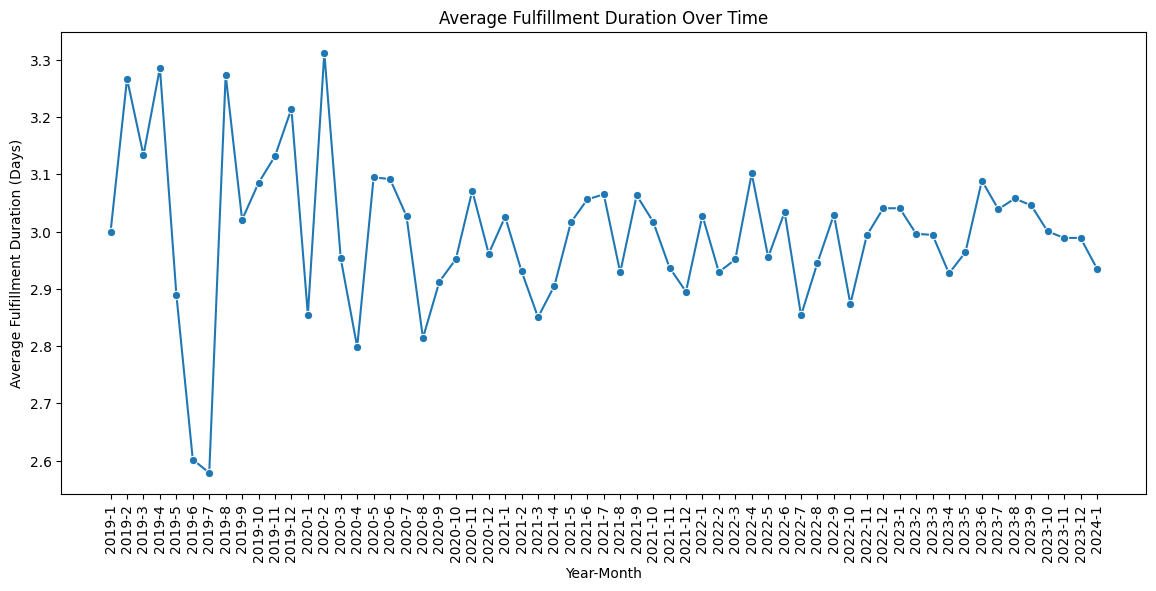

In [ ]:
monthly_fulfillment['year_month'] = (
  monthly_fulfillment['order_year'].astype(str) +
  '-' +
  monthly_fulfillment['order_month'].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
  data=monthly_fulfillment,
  x='year_month',
  y='avg_fulfillment_duration',
  marker='o'
)

plt.xticks(rotation=90)

plt.title('Average Fulfillment Duration Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Fulfillment Duration (Days)')

plt.show()

#### **c. Fulfillment Duration by Product Category**

In [ ]:
category_fulfillment = (
  df_order_items_cleaned
  .merge(
    df_products_cleaned,
    left_on='product_id',
    right_on='id',
    how='left'
  )
  .groupby('category')['fulfillment_duration_days']
  .mean()
  .sort_values(ascending=False)
  .reset_index()
)

category_fulfillment.head(10)

,category,fulfillment_duration_days
0,Clothing Sets,3.368421
1,Jumpsuits & Rompers,3.069277
2,Skirts,3.043042
3,Accessories,3.042671
4,Pants,3.033485
5,Sweaters,3.024908
6,Leggings,3.024295
7,Tops & Tees,3.015754
8,Outerwear & Coats,3.011008
9,Active,3.003022


##### **Key Findings**

| Category            | Avg Fulfillment Duration |
| ------------------- | -----------------------: |
| Clothing Sets       |               ~3.37 hari |
| Jumpsuits & Rompers |               ~3.07 hari |
| Skirts              |               ~3.04 hari |
| Accessories         |               ~3.04 hari |
| Pants               |               ~3.03 hari |

Perbedaan fulfillment duration antar kategori relatif kecil, dimana mayoritas kategori **berada di sekitar 3 hari fulfillment duration**. Bahkan kategori tertinggi yaitu Clothing Sets hanya ~3.37 hari.

##### **Initial Business Interpretation**

1. Operational Process Relatif Standardized

    Karena tidak ada kategori yang:

    - mengalami delay ekstrem,
    - atau fulfillment inefficiency besar.

    Artinya, **fulfillment workflow kemungkinan sudah cukup standardized antar kategori produk**.

2. High-Revenue Categories Tetap Operationally Stable

    Kategori seperti:

    - Outerwear & Coats,
    - Sweaters,
    - Active,

    tetap memiliki **fulfillment duration yang stabil**.

    Hal ini penting karena kategori sebelumnya;

    - menjadi revenue drivers,
    - profit contributors,
    - sekaligus return-risk categories.

    Namun **operasionalnya masih cukup terkendali**.

3. Revenue Leakage Kemungkinan Bukan Disebabkan Fulfillment Delay

    Sebelumnya sudah bisa dilihat bahwa:

    - return rate cukup tinggi pada beberapa kategori.

    Namun sekarang **fulfillment duration terlihat stabil**.

    Artinya, kemungkinan return behavior lebih dipengaruhi:

    - sizing,
    - fit mismatch,
    - product expectation,

    bukan:

    - shipping delay,
    - fulfillment inefficiency.

4. Clothing Sets Sedikit Lebih Lambat

    Walaupun selisihnya kecil, Clothing Sets memiliki **fulfillment duration tertinggi**.

    Hal ini bisa mengindikasikan:

    - inventory complexity,
    - bundling process,
    - atau lower operational frequency.

    Namun impact-nya masih relatif kecil.

**Visualization**

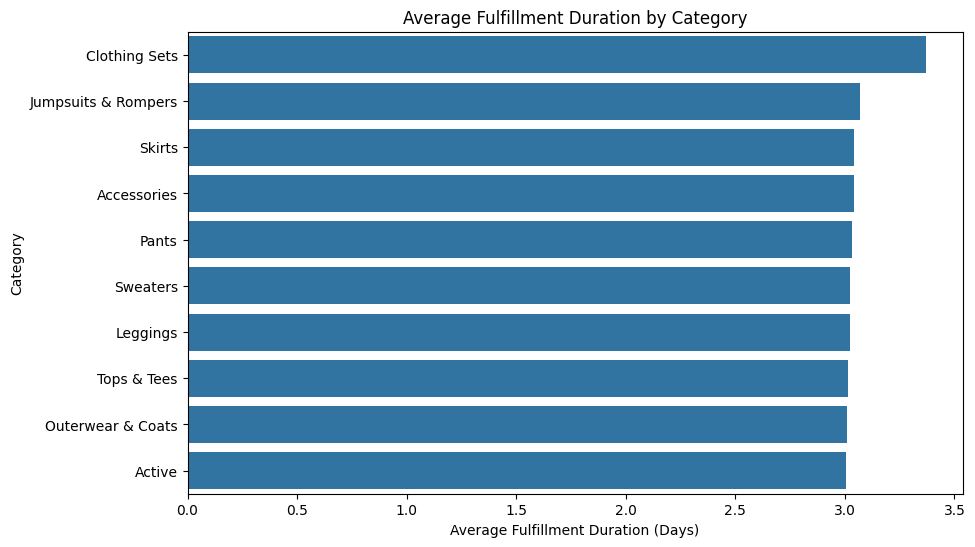

In [ ]:
top_fulfillment_categories = (
  category_fulfillment.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_fulfillment_categories,
  y='category',
  x='fulfillment_duration_days'
)

plt.title('Average Fulfillment Duration by Category')
plt.xlabel('Average Fulfillment Duration (Days)')
plt.ylabel('Category')

plt.show()

#### **d. Return vs Fulfillment Duration**

In [ ]:
return_fulfillment = (
  df_order_items_cleaned
  .groupby('is_returned')['fulfillment_duration_days']
  .mean()
  .reset_index()
)

return_fulfillment['is_returned'] = (
  return_fulfillment['is_returned']
  .map({
    0: 'Not Returned',
    1: 'Returned'
  })
)

return_fulfillment

,is_returned,fulfillment_duration_days
0,Not Returned,2.996457
1,Returned,2.975257


##### **Key Findings**

| Return Status | Avg Fulfillment Duration |
| ------------- | -----------------------: |
| Not Returned  |               ~3.00 hari |
| Returned      |               ~2.98 hari |

Tidak terdapat perbedaan signifikan antara returned dan non-returned orders.

Perbedaan fulfillment duration **sangat kecil (~0.02 hari)**, artinya:

- returned orders,
- dan non-returned orders

memiliki **fulfillment performance yang hampir identik**.

##### **Initial Business Interpretation**

1. Return Behavior Kemungkinan Tidak Dipicu Oleh Fulfillment Delay

    Sebelumnya, beberapa kategori menunjukkan return rate tinggi. Nsamun sekarang, **fulfillment speed tidak menunjukkan hubungan signifikan terhadap return behavior**.

    Artinya, kemungkinan faktor utama return adalah:

    - sizing mismatch,
    - fit issue,
    - customer expectation gap,
    - atau product preference mismatch.

    Bukan keterlambatan operasional.

2. Operational Efficiency Relatif Stabil

    Bahkan produk yang direturn, **tetap diproses dengan kecepatan yang mirip dengan non-returned orders**.

    Temuan ini memperkuat narrative bahwa **fulfillment operations masih berjalan cukup konsisten**.

3. Revenue Leakage Lebih Berkaitan dengan Product Characteristics

    Sejauh ini, beberapa temuan bisa digunakan untuk menghubungkan:

    - high return categories,
    - dengan kemungkinan product-related issue,

    bukan:

    - operational inefficiency.

4. Fulfillment Process Bukan Primary Bottleneck

    Dari seluruh operational analysis sejauh ini:

    - fulfillment duration stabil,
    - trend fulfillment stabil,
    - category fulfillment homogen,
    - return vs fulfillment hampir sama.

    Artinya, **fulfillment operations bukan area risiko utama bisnis saat ini**.

**Visualization**

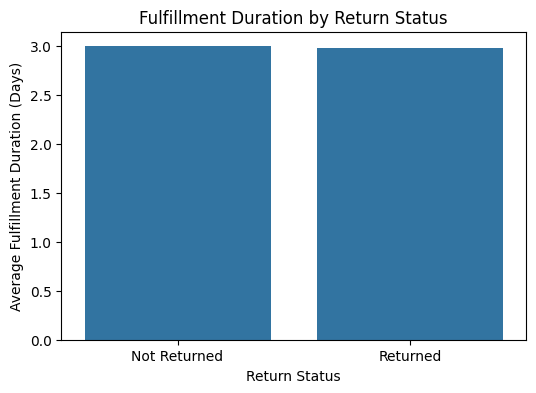

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
  data=return_fulfillment,
  x='is_returned',
  y='fulfillment_duration_days'
)

plt.title('Fulfillment Duration by Return Status')
plt.xlabel('Return Status')
plt.ylabel('Average Fulfillment Duration (Days)')

plt.show()

#### **e. Kesimpulan Insight**

**Operational Scalability & Stability**

1. **Fulfillment process secara umum berjalan cepat dan stabil**

    Mayoritas order diselesaikan dalam waktu sekitar 2–4 hari dengan rata-rata fulfillment duration sekitar 3 hari. Hal ini menunjukkan bahwa proses fulfillment platform relatif efisien dan konsisten dalam menangani order customer.

2. **Pertumbuhan bisnis yang agresif tidak menyebabkan penurunan performa fulfillment**

    Meskipun customer activity dan revenue meningkat sangat signifikan dari tahun ke tahun, rata-rata fulfillment duration tetap stabil sepanjang periode analisis. Hal ini mengindikasikan bahwa operational scalability bisnis masih berjalan dengan baik.

3. **Tidak ditemukan lonjakan fulfillment delay pada periode peak season**

    Pada periode dengan pertumbuhan activity dan revenue tertinggi, khususnya Q4 2023, fulfillment duration tetap berada pada level yang relatif konsisten. Hal ini menunjukkan bahwa sistem operasional dan fulfillment masih mampu menangani peningkatan demand tanpa mengalami bottleneck yang signifikan.

4. **Fulfillment performance antar kategori produk relatif homogen**

    Perbedaan fulfillment duration antar kategori produk cenderung kecil, dengan mayoritas kategori memiliki rata-rata fulfillment sekitar 3 hari. Hal ini mengindikasikan bahwa proses operasional dan fulfillment kemungkinan telah cukup standardized di seluruh product categories.

5. **Tingginya return rate kemungkinan tidak dipengaruhi oleh keterlambatan fulfillment**

    Rata-rata fulfillment duration antara returned orders dan non-returned orders hampir identik. Hal ini menunjukkan bahwa fulfillment delay bukan merupakan faktor utama yang memicu return behavior customer.

6. **Revenue leakage lebih berpotensi dipengaruhi oleh karakteristik produk dibanding operasional fulfillment**

    Karena fulfillment performance relatif stabil sementara return rate tetap tinggi pada beberapa kategori fashion, maka potensi revenue leakage kemungkinan lebih dipengaruhi oleh faktor seperti sizing mismatch, fit inconsistency, atau customer expectation gap dibanding keterlambatan operasional.

### 3.4 Returns & Revenue Leakage Analysis

#### **a. Overall Return Rate Analysis**

In [ ]:
overall_return_rate = (
  df_order_items_cleaned['is_returned'].mean()
) * 100

overall_return_rate

np.float64(28.627342315818645)

##### **Key Findings**

Overall return rate: **~28.63%**

Artinya, **hampir 1 dari 3 item transaction mengalami return**.

Revenue leakage scale tergolong tinggi, dimana return rate hampir 29% **bukan minor operational issue**.

Hal ini masuk ke strategic business risk, karena return behavior dapat memengaruhi:

- realized revenue,
- profitability,
- operational cost,
- reverse logistics burden,
- dan customer experience.

##### **Initial Business Interpretation**

1. Return Behavior Menjadi Salah Satu Risiko Bisnis Utama

    Sebelumnya terlihat bahwa:

    - revenue growth sangat tinggi,
    - profitability cukup sehat.

    Namun sekarang, **return rate menunjukkan adanya hidden business leakage yang besar**.

2. High Growth Belum Tentu Berarti High Revenue Retention

    Walaupun sales meningkat drastis, **sebagian revenue kemungkinan tidak benar-benar retained akibat tingginya return activity**.

3. Potential Profitability Erosion

    Karena return tidak hanya mengurangi revenue, tapi juga:

    - menambah operational cost,  
    - reverse logistics,
    - inventory handling,
    - dan potential markdown risk.

    Artinya, **actual business profitability bisa lebih rendah dari gross sales performance**.

4. Ecommerce Fashion Complexity Sangat Terlihat

    Karena data didominasi fashion products, return rate tinggi **sangat realistis untuk apparel ecommerce**.

    Dan ini konsisten dengan insight sebelumnya, yaitu:

    - size-sensitive products,
    - fit mismatch,
    - expectation gap.

**Visualization**

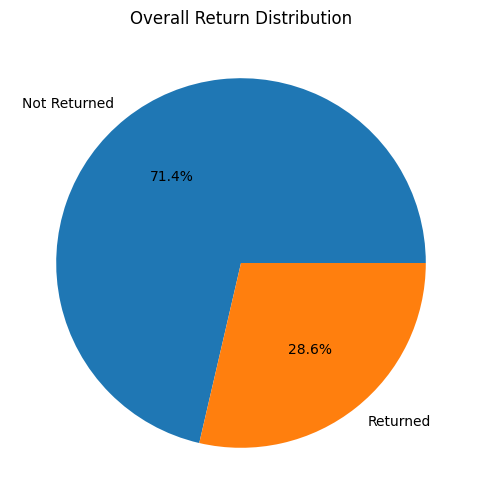

In [ ]:
return_status = (
  df_order_items_cleaned['is_returned']
  .map({
    0: 'Not Returned',
    1: 'Returned'
  })
  .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
  return_status.values,
  labels=return_status.index,
  autopct='%1.1f%%'
)

plt.title('Overall Return Distribution')

plt.show()

#### **b. Revenue Leakage Estimation**

In [ ]:
returned_revenue = (
  df_order_items_cleaned[
    df_order_items_cleaned['is_returned'] == 1]['sale_price'].sum()
)

total_revenue = (
  df_order_items_cleaned['sale_price'].sum()
)

revenue_leakage_pct = (
  returned_revenue / total_revenue
) * 100

returned_revenue, total_revenue, revenue_leakage_pct

(np.float64(1003088.4311747551),
 np.float64(3464629.8839245215),
 np.float64(28.95225362538632))

##### **Key Findings**

| Metric               |   Value |
| -------------------- | ------: |
| Total Revenue        |  ~3.46M |
| Returned Revenue     |  ~1.00M |
| Revenue Leakage Rate | ~28.95% |

Hampir 29% total revenue terdampak return activity, sangat besar.

Artinya, dari total gross revenue ~3.46M, **sekitar 1 juta revenue berpotensi tidak terealisasi secara penuh akibat return behavior**.

##### **Initial Business Interpretation**

1. Revenue Leakage Menjadi Strategic Financial Risk

    Return behavior **bukan lagi sekadar operational issue**, tapi sudah menjadi profitability risk utama.

2. Pertumbuhan Revenue Belum Sepenuhnya Merepresentasikan Realized Revenue

    Karena gross revenue terlihat sangat tinggi dan bertumbuh agresif, **namun hampir sepertiga revenue terdampak return activity**.

    Artinya, **actual retained revenue kemungkinan jauh lebih rendah dari headline revenue performance**.

3. Potential Profit Erosion Sangat Signifikan

    Karena return tidak hanya mengurangi revenue:

    - reverse logistics cost,
    - operational handling,
    - restocking,
    - markdown risk,
    - dan potential inventory aging.

    Hal ini berarti, **dampak profit sebenarnya kemungkinan lebih besar daripada sekadar returned revenue value**.

4. Revenue Growth Perlu Dievaluasi Bersama Leakage Metrics

    Karena business growth **tidak cukup hanya dilihat dari revenue growth**, tetapi juga:

    - retention quality,
    - return behavior,
    - monetization efficiency.

**Visualization**

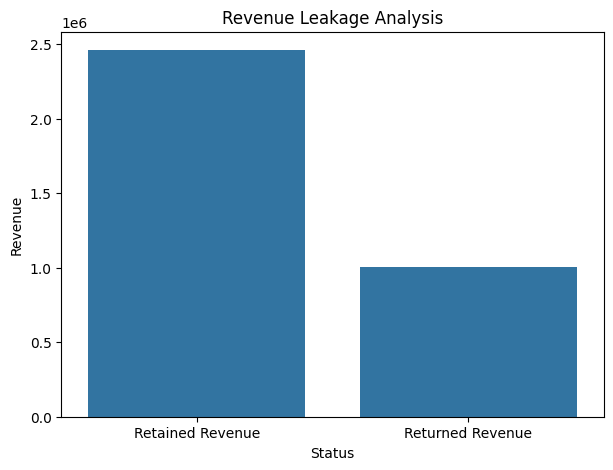

In [ ]:
revenue_status = pd.DataFrame({
  'Status': ['Retained Revenue', 'Returned Revenue'],
  'Value': [
    total_revenue - returned_revenue,
    returned_revenue
  ]
})

plt.figure(figsize=(7,5))

sns.barplot(
  data=revenue_status,
  x='Status',
  y='Value'
)

plt.title('Revenue Leakage Analysis')
plt.ylabel('Revenue')

plt.show()

#### **c. Revenue Leakage by Product Category**

In [ ]:
category_leakage = (
  df_order_items_cleaned[
    df_order_items_cleaned['is_returned'] == 1]
    .merge(
      df_products_cleaned,
      left_on='product_id',
      right_on='id',
      how='left'
    )
    .groupby('category')['sale_price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_leakage.rename(
  columns={'sale_price': 'returned_revenue'},
  inplace=True
)

category_leakage.head(10)

,category,returned_revenue
0,Outerwear & Coats,122664.410027
1,Jeans,111904.790108
2,Sweaters,75385.829964
3,Suits & Sport Coats,66244.219972
4,Swim,59365.540076
5,Fashion Hoodies & Sweatshirts,59188.330063
6,Shorts,50967.720155
7,Sleep & Lounge,45858.770119
8,Active,45603.890085
9,Dresses,43640.650069


##### **Key Findings**

| Category            | Returned Revenue |
| ------------------- | ---------------: |
| Outerwear & Coats   |          ~122.7K |
| Jeans               |          ~111.9K |
| Sweaters            |           ~75.4K |
| Suits & Sport Coats |           ~66.2K |
| Swim                |           ~59.4K |

Kategori revenue driver juga menjadi leakage driver utama, dimana kategori seperti:

- Outerwear & Coats,
- Jeans,
- Sweaters,
- Suits & Sport Coats

tidak hanya:

- menghasilkan revenue tinggi,
- menghasilkan profit tinggi,

tapi juga **menyumbang returned revenue terbesar**.

##### **Initial Business Interpretation**

1. Core Business Categories Menjadi Double-Edged Sword

    Kategori yang menjadi growth engine dan profit engine ternyata juga **menjadi sumber revenue leakage terbesar**.

    Artinya, **business growth saat ini masih memiliki hidden financial inefficiency**.

2. Fashion Categories Memiliki Leakage Risk Tinggi

    Kategori leakage terbesar didominasi **apparel-heavy & fit-sensitive products**.

    Hal ini konsisten dengan insight sebelumnya:

    - sizing issue,
    - fit mismatch,
    - customer expectation gap.

3. Revenue Concentration Sekaligus Risk Concentration

    Karena bisnis tidak hanya terkonsentrasi pada beberapa kategori revenue utama, tapi juga **terkonsentrasi pada kategori leakage utama**.

    Hal ini meningkatkan:

    - operational risk,
    - profitability volatility,
    - dependency risk.

4. Profitability Perlu Dievaluasi Bersama Leakage Exposure

    Walaupun beberapa kategori terlihat sangat profitable, **actual retained profitability kemungkinan lebih rendah setelah memperhitungkan return activity**.

**Visualization**

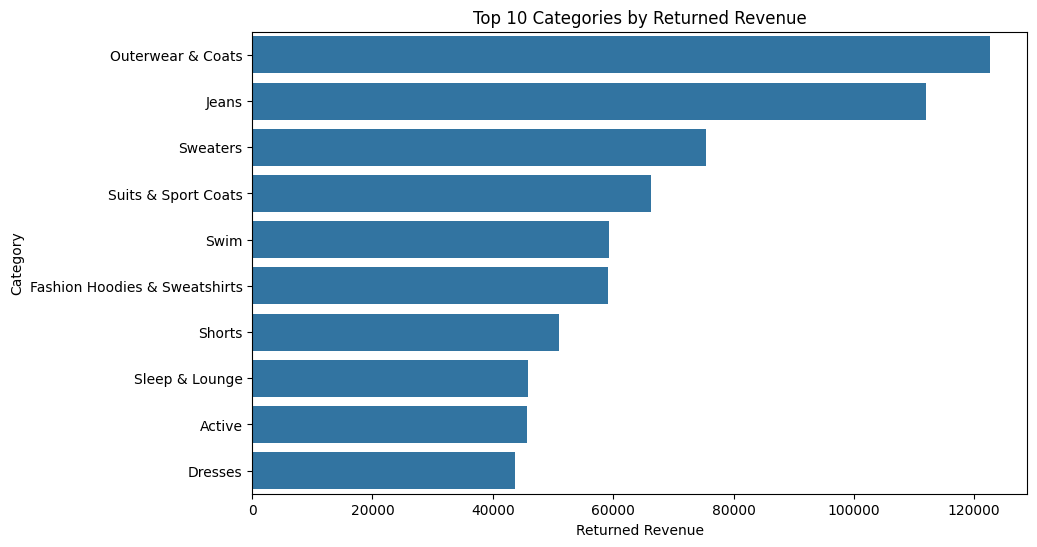

In [ ]:
top_leakage_categories = (
  category_leakage.head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
  data=top_leakage_categories,
  y='category',
  x='returned_revenue'
)

plt.title('Top 10 Categories by Returned Revenue')
plt.xlabel('Returned Revenue')
plt.ylabel('Category')

plt.show()

#### **d. Return Rate Trend Over Time**

In [ ]:
monthly_returns = (
  df_order_items_cleaned
  .groupby(['order_year', 'order_month'])['is_returned']
  .mean()
  .reset_index()
)

monthly_returns['return_rate_pct'] = (
  monthly_returns['is_returned'] * 100
)

monthly_returns

,order_year,order_month,is_returned,return_rate_pct
0,2019,1,0.300000,30.000000
1,2019,2,0.333333,33.333333
2,2019,3,0.366667,36.666667
3,2019,4,0.265306,26.530612
4,2019,5,0.274725,27.472527
...,...,...,...,...
56,2023,9,0.307753,30.775285
57,2023,10,0.296151,29.615110
58,2023,11,0.286244,28.624420
59,2023,12,0.284926,28.492647


##### **Key Findings**

| Observation         | Result           |
| ------------------- | ---------------- |
| Return rate average | ~28–30%          |
| Long-term trend     | relatif stabil   |
| Extreme escalation  | tidak terlihat   |
| Leakage persistence | konsisten tinggi |

Return rate tetap tinggi secara konsisten sepanjang periode bisnis. Meskipun:

- customer activity meningkat drastis,
- revenue meningkat sangat agresif,

**return rate tetap berada di kisaran ~28–30%**.

Artinya, **revenue leakage menjadi persistent structural issue dalam bisnis**.

##### **Initial Business Interpretation**

1. Pertumbuhan Bisnis Tidak Memperburuk Return Rate Secara Signifikan

    Walaupun scale bisnis meningkat sangat besar, **return rate tidak mengalami escalation ekstrem**.

    Artinya:

    - operational scalability cukup baik,
    - leakage growth lebih bersifat proportional daripada exponential.

2. Return Behavior Tampak Menjadi Karakteristik Stabil Bisnis Fashion Ecommerce

    Karena return rate:

    - consistently tinggi,
    - tetapi relatif stabil.

    Hal ini mengindikasikan bahwa **return activity kemungkinan merupakan structural characteristic dari fashion ecommerce model**.

    Bukan:

    - temporary anomaly,
    - atau operational incident.

3. Revenue Leakage Menjadi Persistent Profitability Challenge

    Walaupun bisnis terus bertumbuh, **hampir sepertiga transaction value tetap terdampak return activity**. Hal ini berarti:

    - leakage issue belum terselesaikan,
    - dan masih menjadi hidden profitability pressure.

4. Growth Sustainability Akan Sangat Bergantung pada Leakage Optimization

    Karena jika bisnis ingin:

    - meningkatkan retained profitability,
    - meningkatkan operational efficiency,
    - dan memperkuat monetization quality,

    maka **return optimization harus menjadi strategic priority**.

**Visualization**

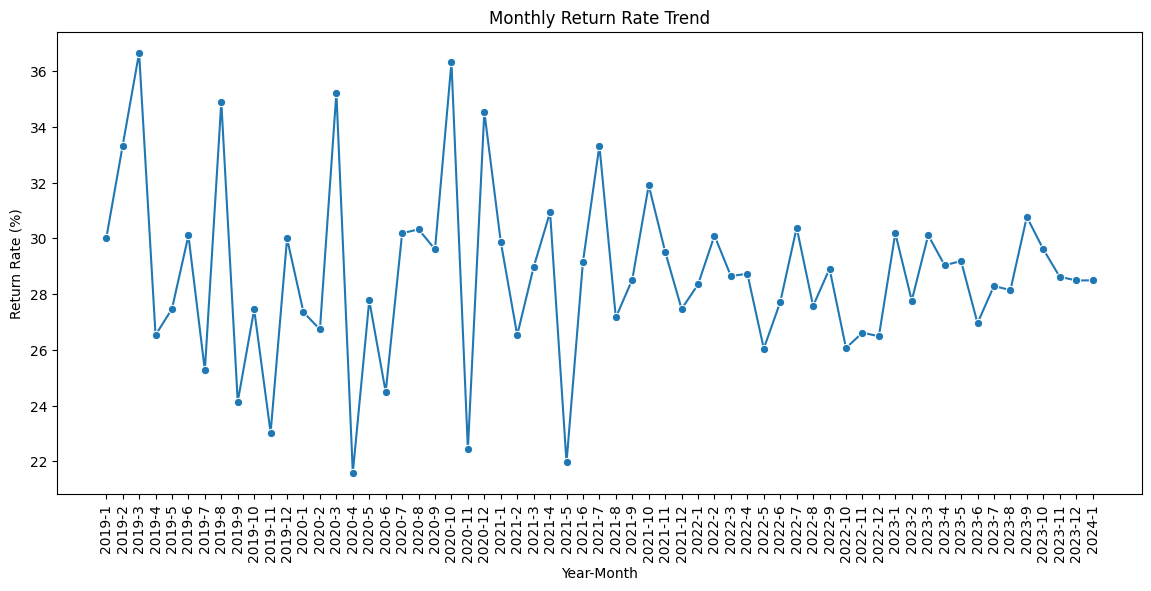

In [ ]:
monthly_returns['year_month'] = (
  monthly_returns['order_year'].astype(str) +
  '-' +
  monthly_returns['order_month'].astype(str)
)

plt.figure(figsize=(14,6))

sns.lineplot(
  data=monthly_returns,
  x='year_month',
  y='return_rate_pct',
  marker='o'
)

plt.xticks(rotation=90)

plt.title('Monthly Return Rate Trend')
plt.xlabel('Year-Month')
plt.ylabel('Return Rate (%)')

plt.show()

#### **e. Kesimpulan Insight**

1. **Return rate bisnis tergolong sangat tinggi**

    Overall return rate mencapai sekitar 28.6%, yang berarti hampir 1 dari 3 item transaction mengalami return. Hal ini menunjukkan bahwa return behavior sudah menjadi salah satu risiko utama dalam operasional dan profitabilitas bisnis ecommerce.

2. **Revenue leakage akibat return activity sangat signifikan**

    Dari total revenue sekitar 3.46 juta, terdapat lebih dari 1 juta revenue yang terdampak return activity. Hal ini menunjukkan bahwa sebagian besar gross revenue bisnis belum sepenuhnya dapat dikonversi menjadi retained revenue.

3. **Kategori revenue driver juga menjadi leakage driver utama**

    Kategori seperti Outerwear & Coats, Jeans, Sweaters, dan Suits & Sport Coats tidak hanya menjadi kontributor revenue dan profit terbesar, tetapi juga menghasilkan returned revenue tertinggi. Hal ini menunjukkan bahwa bisnis memiliki konsentrasi risiko leakage pada kategori core product utama.

4. **Revenue leakage kemungkinan dipengaruhi oleh karakteristik produk fashion**

    Kategori dengan leakage tertinggi didominasi oleh produk apparel yang bersifat size-sensitive dan fit-sensitive. Hal ini mengindikasikan bahwa sizing mismatch, fit inconsistency, dan customer expectation gap kemungkinan menjadi faktor utama tingginya return behavior.

5. **Return behavior bersifat konsisten sepanjang pertumbuhan bisnis**

    Meskipun customer activity dan revenue meningkat sangat signifikan dari tahun ke tahun, return rate tetap berada pada kisaran sekitar 28–30%. Hal ini menunjukkan bahwa revenue leakage merupakan structural issue yang konsisten dalam model bisnis fashion ecommerce.

6. **Optimasi return management berpotensi menjadi area peningkatan profitabilitas terbesar**

    Karena fulfillment operations relatif stabil sementara return rate tetap tinggi, maka peluang peningkatan retained profitability kemungkinan lebih besar berasal dari pengurangan return behavior dibanding peningkatan operational speed.

## Tahap 4 — Insight & Interpretation

### 4.1 Business Growth & Customer Acquisition Insights

#### **Insight 1 - Customer Activity Growth Shows Strong Platform Expansion**

Customer activity mengalami pertumbuhan yang sangat signifikan dari tahun ke tahun, terlihat dari peningkatan total events bulanan yang meningkat lebih dari lima kali lipat sejak awal periode dataset. Pertumbuhan ini menunjukkan bahwa platform TheLook berhasil meningkatkan customer engagement dan memperluas aktivitas pengguna secara konsisten sepanjang periode bisnis.

Selain itu, peningkatan activity yang terus berlanjut hingga akhir 2023 mengindikasikan bahwa pertumbuhan platform masih berada dalam fase ekspansi dan belum menunjukkan tanda penurunan engagement secara signifikan.

#### **Business Interpretation**

Pertumbuhan customer activity yang konsisten menunjukkan bahwa strategi acquisition dan platform exposure berjalan cukup efektif dalam meningkatkan user engagement dan platform adoption.

#### **Insight 2 — Business Depends Heavily on Email and Adwords Acquisition Channels**

Traffic platform didominasi oleh Email dan Adwords yang secara gabungan menyumbang hampir 75% total customer activity dan session. Hal ini menunjukkan bahwa bisnis masih memiliki ketergantungan yang cukup tinggi terhadap acquisition-driven traffic dan paid/directed marketing channels.

Sementara itu, kontribusi Organic traffic masih relatif rendah dibanding channel lainnya.

#### **Business Interpretation**

Ketergantungan tinggi terhadap beberapa acquisition channels meningkatkan risiko concentration dependency apabila performa campaign menurun atau acquisition cost meningkat di masa mendatang.

#### **Insight 3 — Conversion Efficiency Across Traffic Sources Is Relatively Similar**

Meskipun volume traffic antar channel sangat berbeda, seluruh traffic source menunjukkan conversion rate yang relatif homogen pada kisaran sekitar 7.4–7.5%.

Hal ini menunjukkan bahwa dominasi traffic lebih dipengaruhi oleh volume acquisition dibanding perbedaan kualitas conversion antar channel.

#### **Business Interpretation**

Tidak terdapat indikasi major conversion inefficiency antar traffic source. Namun, Organic traffic menunjukkan conversion quality yang cukup kompetitif meskipun volume traffic masih rendah, sehingga berpotensi menjadi area growth opportunity yang belum dimanfaatkan secara optimal.

#### **Insight 4 — Customer Activity Shows Strong Temporal Behavior Patterns**

Aktivitas customer cenderung terkonsentrasi pada pagi hingga siang hari, khususnya pada rentang waktu 06:00–11:00. Aktivitas mulai menurun pada sore hari dan mengalami penurunan signifikan pada malam hari.

#### **Business Interpretation**

Pola temporal behavior ini menunjukkan bahwa timing dapat menjadi faktor penting dalam optimasi campaign deployment, customer engagement strategy, dan promotional scheduling.

### 4.2 Revenue & Profitability Insights

#### **Insight 1 — Revenue Growth Increased Aggressively Alongside Customer Expansion**

Revenue bisnis menunjukkan pertumbuhan yang sangat signifikan sepanjang periode analisis. Total monthly revenue meningkat dari skala ribuan pada awal 2019 menjadi lebih dari 800 ribu pada awal 2024.

Peningkatan ini berjalan searah dengan pertumbuhan customer activity yang sebelumnya telah ditemukan pada analisis customer acquisition, menunjukkan bahwa peningkatan engagement berhasil dikonversi menjadi pertumbuhan monetisasi yang nyata.

#### **Business Interpretation**

TheLook berhasil melakukan scaling bisnis secara agresif dengan tetap mempertahankan kemampuan monetisasi platform. Pertumbuhan revenue yang konsisten menunjukkan bahwa peningkatan traffic dan customer activity masih mampu menghasilkan transaksi dan purchase activity yang sehat.

#### **Insight 2 — Revenue and Profitability Are Highly Concentrated in Core Fashion Categories**

Kategori seperti Outerwear & Coats, Jeans, dan Sweaters menjadi kontributor utama baik terhadap revenue maupun profit bisnis. Beberapa kategori fashion utama tidak hanya menghasilkan transaction volume yang tinggi, tetapi juga menjadi profit engine terbesar dalam platform.

Hal ini menunjukkan bahwa performa bisnis TheLook masih sangat bergantung pada beberapa core apparel categories tertentu.

#### **Business Interpretation**

Ketergantungan tinggi terhadap beberapa kategori utama meningkatkan concentration risk bisnis. Penurunan demand atau perubahan trend pada kategori utama dapat memberikan dampak signifikan terhadap overall revenue dan profitability platform.

#### **Insight 3 — High Revenue Does Not Always Indicate High Monetization Efficiency**

Analisis profit margin menunjukkan bahwa beberapa kategori seperti Blazers & Jackets, Accessories, dan Suits & Sport Coats memiliki profit margin tertinggi meskipun bukan kontributor revenue terbesar.

Sebaliknya, beberapa kategori dengan revenue besar tidak selalu memiliki monetization efficiency terbaik.

#### **Business Interpretation**

Evaluasi performa bisnis tidak dapat hanya berfokus pada revenue contribution semata. Margin efficiency perlu dipertimbangkan dalam pengambilan keputusan terkait inventory prioritization, campaign allocation, dan category expansion strategy.

#### **Insight 4 — Business Growth Remains Financially Healthy Despite Rapid Scaling**

Meskipun bisnis mengalami pertumbuhan yang sangat agresif, sebagian besar kategori utama masih menunjukkan profitabilitas yang relatif sehat. Revenue growth dan profit growth masih bergerak secara searah pada mayoritas strategic categories.

#### **Business Interpretation**

Pertumbuhan bisnis TheLook masih menunjukkan kualitas monetisasi yang cukup baik. Hal ini mengindikasikan bahwa scaling bisnis sejauh ini belum menyebabkan penurunan profitabilitas secara signifikan pada core product categories.

#### **Insight 5 — Several Strategic Categories Simultaneously Become Revenue Leakage Contributors**

Beberapa kategori yang menjadi kontributor utama revenue dan profit, seperti Outerwear & Coats dan Suits & Sport Coats, juga menghasilkan returned revenue yang tinggi.

Hal ini menunjukkan bahwa sebagian business growth masih dibayangi oleh potensi revenue leakage yang cukup besar pada strategic categories utama.

#### **Business Interpretation**

Business growth TheLook masih menghadapi hidden profitability pressure akibat tingginya return behavior pada beberapa kategori fashion utama. Oleh karena itu, evaluasi performa kategori perlu mempertimbangkan retained profitability, bukan hanya gross sales performance.

### 4.3 Operational Performance Insights

#### **Insight 1 — Fulfillment Operations Remain Stable Despite Rapid Business Growth**

Rata-rata fulfillment duration berada pada kisaran sekitar 3 hari dan relatif stabil sepanjang periode analisis. Meskipun customer activity dan revenue mengalami pertumbuhan yang sangat signifikan, performa fulfillment tidak menunjukkan penurunan yang ekstrem.

Selain itu, variasi fulfillment duration juga relatif rendah pada mayoritas order.

#### **Business Interpretation**

TheLook menunjukkan kemampuan operational scalability yang cukup baik. Pertumbuhan bisnis yang agresif sejauh ini masih dapat diimbangi oleh kapasitas fulfillment dan operational process yang relatif stabil.

#### **Insight 2 — No Significant Operational Bottleneck Was Found During Peak Growth Periods**

Pada periode dengan pertumbuhan activity dan revenue tertinggi, khususnya sepanjang 2023 hingga awal 2024, fulfillment duration tetap berada pada level yang relatif konsisten tanpa lonjakan delay yang signifikan.

Hal ini menunjukkan bahwa peningkatan transaction volume belum menyebabkan degradation besar pada operational performance.

#### **Business Interpretation**

Operational workflow dan fulfillment capacity kemungkinan telah berkembang seiring pertumbuhan bisnis, sehingga platform masih mampu mempertahankan delivery consistency pada periode high demand.

#### **Insight 3 — Fulfillment Performance Is Relatively Consistent Across Product Categories**

Analisis fulfillment duration antar kategori menunjukkan perbedaan yang relatif kecil, dengan mayoritas kategori memiliki rata-rata fulfillment sekitar 3 hari.

Tidak terdapat kategori yang menunjukkan fulfillment delay ekstrem dibanding kategori lainnya.

#### **Business Interpretation**

Proses fulfillment TheLook kemungkinan telah cukup standardized pada sebagian besar product categories. Hal ini membantu menjaga consistency customer experience dan mengurangi risiko operational inefficiency pada kategori tertentu.

#### **Insight 4 — High Return Behavior Is Likely Not Caused by Fulfillment Delays**

Perbandingan fulfillment duration antara returned orders dan non-returned orders menunjukkan hasil yang hampir identik. Returned orders tidak memiliki fulfillment duration yang secara signifikan lebih lambat dibanding order lainnya.

Hal ini mengindikasikan bahwa fulfillment delay bukan faktor utama yang memengaruhi tingginya return behavior customer.

#### **Business Interpretation**

Potensi revenue leakage pada platform kemungkinan lebih dipengaruhi oleh product-related issues seperti sizing mismatch, fit inconsistency, atau customer expectation gap dibanding masalah operational fulfillment.

#### **Insight 5 — Operational Stability Supports Long-Term Business Scalability**

Konsistensi fulfillment performance di tengah pertumbuhan revenue dan transaction volume menunjukkan bahwa operasional TheLook masih berada dalam kondisi yang relatif sehat dan scalable.

Tidak terdapat indikasi kuat bahwa fulfillment operations menjadi bottleneck utama dalam pertumbuhan bisnis saat ini.

#### **Business Interpretation**

Operational stability menjadi salah satu faktor penting yang membantu TheLook mempertahankan customer experience dan mendukung sustainability business growth dalam jangka panjang.

### 4.4 Revenue Leakage & Return Risk Insights

#### **Insight 1 — Product Returns Represent a Significant Revenue Leakage Risk**

Overall return rate pada platform mencapai sekitar 28–29%, yang berarti hampir sepertiga item transaction mengalami return activity. Selain itu, lebih dari 1 juta revenue terdampak oleh returned orders dari total revenue sekitar 3.46 juta.

Hal ini menunjukkan bahwa return behavior bukan lagi sekadar operational issue, tetapi telah menjadi strategic financial risk bagi bisnis.

#### **Business Interpretation**

Tingginya return activity berpotensi mengurangi retained revenue, menekan profitabilitas, dan meningkatkan reverse logistics cost pada platform ecommerce TheLook.

#### **Insight 2 — Revenue Leakage Is Highly Concentrated in Strategic Fashion Categories**

Kategori seperti Outerwear & Coats, Jeans, Sweaters, dan Suits & Sport Coats menjadi kontributor terbesar terhadap returned revenue.

Menariknya, kategori tersebut sebelumnya juga merupakan strategic revenue dan profit drivers utama dalam platform.

#### **Business Interpretation**

TheLook menghadapi concentration risk yang cukup tinggi karena kategori yang menopang pertumbuhan revenue sekaligus menjadi sumber leakage terbesar dalam bisnis.

#### **Insight 3 — Return Behavior Appears to Be a Structural Characteristic of the Business**

Analisis return trend menunjukkan bahwa return rate tetap berada pada kisaran sekitar 28–30% sepanjang periode bisnis meskipun customer activity dan revenue meningkat secara signifikan.

Tidak terdapat escalation ekstrem pada return rate seiring pertumbuhan bisnis.

#### **Business Interpretation**

Return behavior kemungkinan merupakan structural characteristic dari fashion ecommerce business model, terutama pada kategori apparel yang bersifat fit-sensitive dan size-sensitive.

#### **Insight 4 — Product Characteristics Likely Influence Return Behavior More Than Operational Factors**

Kategori dengan return rate dan returned revenue tertinggi didominasi oleh kategori apparel seperti suits, outerwear, pants, dan jumpsuits yang memiliki kompleksitas sizing dan fit yang lebih tinggi.

Di sisi lain, fulfillment performance antara returned orders dan non-returned orders menunjukkan hasil yang hampir identik.

#### **Business Interpretation**

Faktor seperti sizing mismatch, fit inconsistency, dan customer expectation gap kemungkinan memiliki pengaruh yang lebih besar terhadap return behavior dibanding keterlambatan operasional fulfillment.

#### **Insight 5 — Return Optimization Represents One of the Largest Profitability Improvement Opportunities**

Karena fulfillment operations relatif stabil sementara return rate tetap tinggi, maka peluang peningkatan retained profitability kemungkinan lebih besar berasal dari pengurangan return activity dibanding peningkatan operational speed.

#### **Business Interpretation**

Strategi seperti sizing optimization, product information enhancement, customer review utilization, dan category-specific return mitigation berpotensi memberikan dampak signifikan terhadap peningkatan monetization quality dan retained profitability bisnis.

## Tahap 5 — Pembuatan Dashboard (Check Notebook 3)